# Cross-store and annual product seasonality

## Thresholds used

- **Upstream input filter:** FCM product-store series require at least 30 active days and 10 positive-demand days; Pseudo series require at least 120 active days and 30 positive-demand days.
- **Stable annual profiles:** only ISO years 2024 and 2025; each product-store series must occur in both years, have at least 40 observed weeks per year, and have positive annual demand. Product-level analysis requires at least 10 eligible stores.
- **Seasonal-family audit:** `seasonal_cv >= 0.25`, median cross-store correlation `>= 0.50`, and fixed-week year correlation `>= 0.30`. These audit the curated members; they do not silently remove exceptions. Easter uses event alignment instead of the fixed-week repeatability cutoff, with a displayed window of ±7 weeks around Easter.
- **Daily ADI–CV² support:** at least 10 positive-demand days; ADI cutoff 1.32 and CV² cutoff 0.49.
- **Recent FCM cross-store view:** starts 14 April 2025; each FCM store series requires at least 12 weeks and positive total demand; displayed products require at least 10 qualifying stores.
- **Provisional FCM family assignment:** at least 10 stores and 26 profile weeks. Strong means best family correlation `>= 0.60` with margin `>= 0.10`; tentative means correlation `>= 0.30` with margin `>= 0.05`.
- **Reference-only plot lines:** the seasonality-landscape lines at correlation 0.50 and seasonal CV 0.25 are visual guides; the disconnected-product section uses relative ranks rather than a fixed cutoff.

This notebook answers three related questions:

1. **Cross-store agreement:** do stores show the same normalized ISO-week shape?
2. **Annual repetition:** does that shape repeat in the complete years 2024 and 2025?
3. **Seasonal families:** how were the barbecue/summer, Christmas-roast, and Easter-lamb groups determined?
4. **FCM cross-store agreement:** which recent FCM products move together across stores, despite their shorter histories?

Demand is aggregated weekly and normalized within each store/year, so large and small stores can be compared by shape. The stable-season analysis uses the complete ISO years **2024–2025**. The available data starts on 22 July 2023, so 2023 is excluded from full-year comparisons. FCM is analysed separately because its history starts in April 2025.

The recurring **day-of-week** question is deliberately separated into `01_04_weekly_seasonality_fcm_pseudo.ipynb`; FCM–Pseudo product connections and the controlling-team mapping are analysed in `01_05_fcm_pseudo_correlations.ipynb`.

In [16]:
import warnings
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR_CANDIDATES = [
    Path("../../data/processed/transactions"),
    Path("data/processed/transactions"),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    searched = ", ".join(str(path) for path in DATA_DIR_CANDIDATES)
    raise FileNotFoundError(f"No input data directory found. Searched: {searched}")
if not any(DATA_DIR.glob("*.parquet")):
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")
DATA_GLOB = str(DATA_DIR / "*.parquet")

FULL_YEARS = (2024, 2025)
FULL_YEARS_SQL = ", ".join(map(str, FULL_YEARS))
FULL_YEAR_LABEL = "–".join(map(str, FULL_YEARS))
MIN_OBSERVED_WEEKS = 40
REFERENCE_ARTICLE_ID = 317123
MIN_STORES = 10
RECENT_START = "2025-04-14"

SOURCE_COLORS = {"Pseudo": "#E3A83B", "FCM": "#D45D45"}
GROUP_COLORS = {
    "Barbecue / summer": "#E76F51",
    "Christmas roasts": "#6D597A",
    "Easter lamb": "#2A9D8F",
}
GROUP_LABELS = {
    "Barbecue / summer": "Grillen / Sommer",
    "Christmas roasts": "Weihnachtsbraten",
    "Easter lamb": "Osterlamm",
}
ADI_CLASS_LABELS = {
    "smooth": "gleichmäßig", "erratic": "schwankend",
    "intermittent": "sporadisch", "lumpy": "unregelmäßig",
}
CONFIDENCE_LABELS = {
    "Strong": "stark", "Tentative": "vorläufig",
    "Unassigned": "nicht zugeordnet",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

con = duckdb.connect()
con.execute("PRAGMA threads=4")

data_coverage = con.execute(f"""
SELECT
    min(DATE::DATE) AS first_date,
    max(DATE::DATE) AS last_date,
    count(DISTINCT ARTIKEL_ID) AS products,
    count(DISTINCT MARKT_ID) AS stores
FROM read_parquet('{DATA_GLOB}')
""").fetchdf()
display(data_coverage)

first_sale_by_source = con.execute(f"""
SELECT
    CASE
        WHEN is_fcm THEN 'FCM'
        WHEN is_pseudo THEN 'Pseudo'
        ELSE 'Other'
    END || ' ' || WGR_ID::VARCHAR AS sourcing_group,
    min(DATE::DATE) AS first_sale_date,
    count(*) AS positive_rows
FROM read_parquet('{DATA_GLOB}')
WHERE ABVERKAUFTE_MENGE_KG > 0
  AND (is_fcm OR is_pseudo)
GROUP BY sourcing_group
ORDER BY sourcing_group
""").fetchdf()
display(first_sale_by_source)

,first_date,last_date,products,stores
0,2023-07-22,2026-07-21,326,192


,sourcing_group,first_sale_date,positive_rows
0,FCM 890,2025-09-16,10296
1,FCM 900,2025-04-17,332056
2,Pseudo 890,2023-07-22,6052694
3,Pseudo 900,2023-07-22,20723


## 1. Stable weekly seasonality (2024–2025)

A product/store pair is retained when it occurs in both complete ISO years, has at least 40 observed weeks per year, and positive annual demand. Missing weeks inside an eligible series are filled with zero. Each store-year is divided by its own mean weekly demand.

ISO year and ISO week are used together, avoiding the calendar-boundary error where, for example, 31 December can belong to week 1 of the following ISO year.

The main metrics are:

- **Store agreement:** median correlation of each store's normalized weekly curve with the product's cross-store median curve.
- **Year repeatability:** correlation between the 2024 and 2025 product profiles.
- **Seasonal CV:** variation of the 52-week mean profile; larger values indicate a more concentrated season.

In [17]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE weekly_full AS
SELECT
    ARTIKEL_ID AS article_id,
    any_value(ARTIKEL_BEZ) AS product_name,
    CASE
        WHEN bool_or(is_fcm) THEN 'FCM'
        WHEN bool_or(is_pseudo) THEN 'Pseudo'
    END AS source_class,
    MARKT_ID AS store_id,
    isoyear(DATE::DATE) AS sales_year,
    week(DATE::DATE) AS sales_week,
    sum(ABVERKAUFTE_MENGE_KG) AS demand_kg
FROM read_parquet('{DATA_GLOB}')
WHERE is_active
  AND isoyear(DATE::DATE) IN ({FULL_YEARS_SQL})
  AND (is_fcm OR is_pseudo)
GROUP BY ARTIKEL_ID, MARKT_ID, isoyear(DATE::DATE), week(DATE::DATE)
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE eligible_product_stores AS
WITH yearly_coverage AS (
    SELECT
        article_id,
        store_id,
        sales_year,
        count(*) AS observed_weeks,
        sum(demand_kg) AS annual_demand
    FROM weekly_full
    GROUP BY article_id, store_id, sales_year
),
complete_year_coverage AS (
    SELECT
        article_id,
        store_id,
        count(*) AS covered_years,
        min(observed_weeks) AS min_observed_weeks,
        min(annual_demand) AS min_annual_demand
    FROM yearly_coverage
    GROUP BY article_id, store_id
)
SELECT article_id, store_id
FROM complete_year_coverage
WHERE covered_years = {len(FULL_YEARS)}
  AND min_observed_weeks >= {MIN_OBSERVED_WEEKS}
  AND min_annual_demand > 0
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE normalized_store_year_week AS
WITH grid AS (
    SELECT e.article_id, e.store_id, y.sales_year, w.sales_week
    FROM eligible_product_stores e
    CROSS JOIN unnest([{FULL_YEARS_SQL}]) y(sales_year)
    CROSS JOIN range(1, 53) w(sales_week)
),
filled AS (
    SELECT
        g.article_id,
        g.store_id,
        g.sales_year,
        g.sales_week,
        coalesce(w.demand_kg, 0.0) AS demand_kg
    FROM grid g
    LEFT JOIN weekly_full w USING (article_id, store_id, sales_year, sales_week)
),
with_mean AS (
    SELECT
        *,
        avg(demand_kg) OVER (
            PARTITION BY article_id, store_id, sales_year
        ) AS mean_weekly_demand
    FROM filled
)
SELECT
    article_id,
    store_id,
    sales_year,
    sales_week,
    demand_kg / nullif(mean_weekly_demand, 0) AS normalized_demand
FROM with_mean
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE product_year_profile AS
SELECT
    article_id,
    sales_year,
    sales_week,
    median(normalized_demand) AS profile_value
FROM normalized_store_year_week
GROUP BY article_id, sales_year, sales_week
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE product_profile AS
SELECT article_id, sales_week, avg(profile_value) AS profile_value
FROM product_year_profile
GROUP BY article_id, sales_week
""")

metrics = con.execute("""
WITH store_correlations AS (
    SELECT
        n.article_id,
        n.store_id,
        n.sales_year,
        corr(n.normalized_demand, p.profile_value) AS store_correlation
    FROM normalized_store_year_week n
    JOIN product_year_profile p USING (article_id, sales_year, sales_week)
    GROUP BY n.article_id, n.store_id, n.sales_year
),
cross_store AS (
    SELECT
        article_id,
        median(store_correlation) AS median_store_correlation
    FROM store_correlations
    GROUP BY article_id
),
year_pairs AS (
    SELECT
        a.article_id,
        a.sales_year AS year_a,
        b.sales_year AS year_b,
        corr(a.profile_value, b.profile_value) AS year_correlation
    FROM product_year_profile a
    JOIN product_year_profile b
      ON a.article_id = b.article_id
     AND a.sales_week = b.sales_week
     AND a.sales_year < b.sales_year
    GROUP BY a.article_id, a.sales_year, b.sales_year
),
year_metrics AS (
    SELECT
        article_id,
        median(year_correlation) AS median_year_correlation,
        min(year_correlation) AS minimum_year_correlation
    FROM year_pairs
    GROUP BY article_id
),
profile_metrics AS (
    SELECT
        article_id,
        stddev_samp(profile_value) / nullif(avg(profile_value), 0) AS seasonal_cv,
        max(profile_value) / nullif(avg(profile_value), 0) AS peak_multiple,
        arg_max(sales_week, profile_value) AS peak_week
    FROM product_profile
    GROUP BY article_id
),
store_counts AS (
    SELECT article_id, count(*) AS eligible_stores
    FROM eligible_product_stores
    GROUP BY article_id
),
names AS (
    SELECT
        article_id,
        any_value(product_name) AS product_name,
        any_value(source_class) AS source_class
    FROM weekly_full
    GROUP BY article_id
)
SELECT
    n.*,
    s.eligible_stores,
    c.median_store_correlation,
    y.median_year_correlation,
    y.minimum_year_correlation,
    p.seasonal_cv,
    p.peak_multiple,
    p.peak_week,
    p.seasonal_cv
      * greatest(c.median_store_correlation, 0)
      * greatest(y.median_year_correlation, 0) AS seasonal_score
FROM names n
JOIN store_counts s USING (article_id)
JOIN cross_store c USING (article_id)
JOIN year_metrics y USING (article_id)
JOIN profile_metrics p USING (article_id)
ORDER BY seasonal_score DESC NULLS LAST
""").fetchdf()

analysis_metrics = metrics[metrics["eligible_stores"] >= MIN_STORES].copy()
if analysis_metrics.empty:
    raise ValueError("No products survived the complete-year eligibility rules")

print(
    f"Products with at least {MIN_STORES} eligible stores in {FULL_YEAR_LABEL}: "
    f"{len(analysis_metrics):,}"
)
display(analysis_metrics[analysis_metrics.article_id == REFERENCE_ARTICLE_ID])

Products with at least 10 eligible stores in 2024–2025: 174


,article_id,product_name,source_class,eligible_stores,median_store_correlation,median_year_correlation,minimum_year_correlation,seasonal_cv,peak_multiple,peak_week,seasonal_score
60,317123,"Nackensteak mariniert, vom Schwein",Pseudo,180,0.939253,0.526295,0.526295,0.781728,2.707823,22,0.386427


## 2. Seasonality landscape

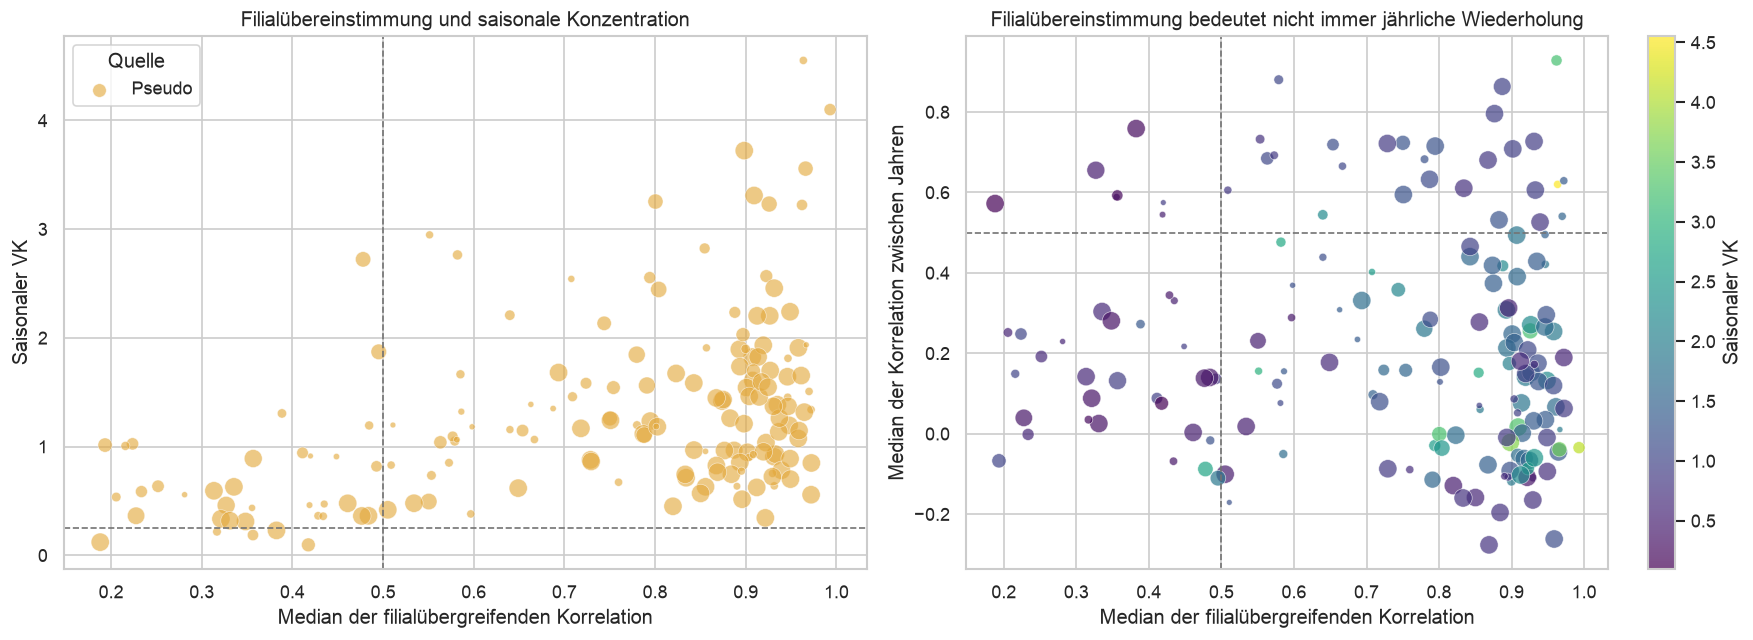

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for source_class, group in analysis_metrics.groupby("source_class"):
    axes[0].scatter(
        group.median_store_correlation,
        group.seasonal_cv,
        s=np.clip(group.eligible_stores, 10, 100) * 1.2,
        alpha=0.62,
        color=SOURCE_COLORS[source_class],
        label=source_class,
        edgecolor="white",
        linewidth=0.4,
    )
axes[0].axvline(0.5, color="0.45", linestyle="--", linewidth=1)
axes[0].axhline(0.25, color="0.45", linestyle="--", linewidth=1)
axes[0].set_xlabel("Median der filialübergreifenden Korrelation")
axes[0].set_ylabel("Saisonaler VK")
axes[0].set_title("Filialübereinstimmung und saisonale Konzentration")
axes[0].legend(title="Quelle")

scatter = axes[1].scatter(
    analysis_metrics.median_store_correlation,
    analysis_metrics.median_year_correlation,
    c=analysis_metrics.seasonal_cv,
    cmap="viridis",
    s=np.clip(analysis_metrics.eligible_stores, 10, 100) * 1.2,
    alpha=0.7,
    edgecolor="white",
    linewidth=0.4,
)
axes[1].axvline(0.5, color="0.45", linestyle="--", linewidth=1)
axes[1].axhline(0.5, color="0.45", linestyle="--", linewidth=1)
axes[1].set_xlabel("Median der filialübergreifenden Korrelation")
axes[1].set_ylabel("Median der Korrelation zwischen Jahren")
axes[1].set_title("Filialübereinstimmung bedeutet nicht immer jährliche Wiederholung")
fig.colorbar(scatter, ax=axes[1], label="Saisonaler VK")

fig.tight_layout()
plt.show()


## 3. Nackensteak: synchronized across stores

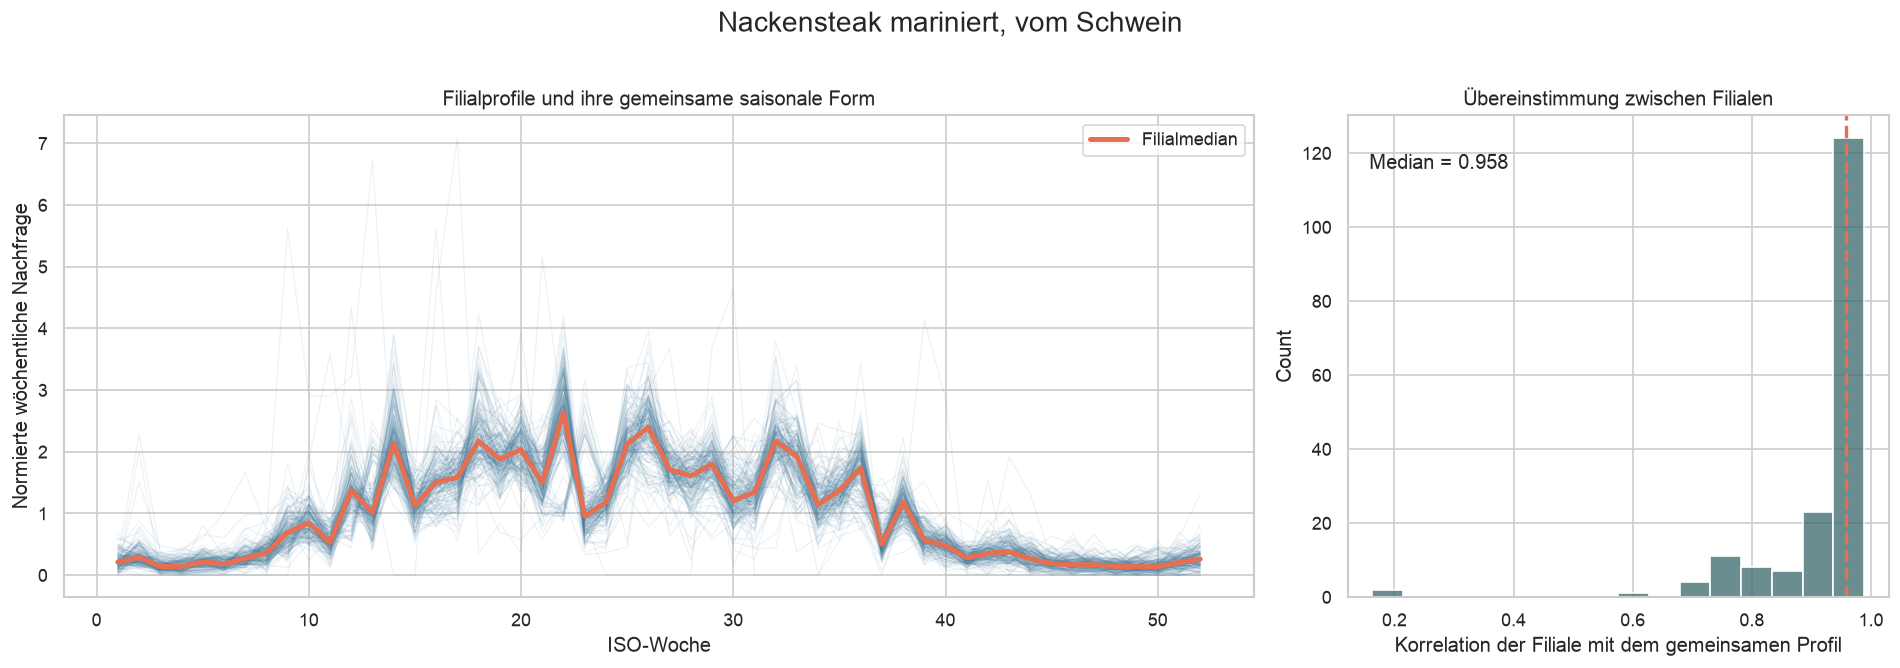

In [19]:
nacken_store_profiles = con.execute(f"""
    SELECT
        store_id,
        sales_week,
        avg(normalized_demand) AS normalized_demand
    FROM normalized_store_year_week
    WHERE article_id = {REFERENCE_ARTICLE_ID}
    GROUP BY store_id, sales_week
    ORDER BY store_id, sales_week
""").fetchdf()

nacken_matrix = nacken_store_profiles.pivot(
    index="store_id", columns="sales_week", values="normalized_demand"
)
nacken_reference = nacken_matrix.median(axis=0)
nacken_correlations = nacken_matrix.apply(lambda row: row.corr(nacken_reference), axis=1)
nacken_matrix = nacken_matrix.loc[nacken_correlations.sort_values(ascending=False).index]

fig, (ax_lines, ax_hist) = plt.subplots(
    1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [2.2, 1]}
)
for _, row in nacken_matrix.iterrows():
    ax_lines.plot(row.index, row.values, color="#457B9D", alpha=0.10, linewidth=0.7)
ax_lines.plot(
    nacken_reference.index,
    nacken_reference.values,
    color="#E76F51",
    linewidth=3,
    label="Filialmedian",
)
ax_lines.set_xlabel("ISO-Woche")
ax_lines.set_ylabel("Normierte wöchentliche Nachfrage")
ax_lines.set_title("Filialprofile und ihre gemeinsame saisonale Form")
ax_lines.legend()

sns.histplot(nacken_correlations, bins=16, color="#38686A", ax=ax_hist)
ax_hist.axvline(nacken_correlations.median(), color="#E76F51", linestyle="--", linewidth=2)
ax_hist.text(
    0.04,
    0.92,
    f"Median = {nacken_correlations.median():.3f}",
    transform=ax_hist.transAxes,
    va="top",
)
ax_hist.set_xlabel("Korrelation der Filiale mit dem gemeinsamen Profil")
ax_hist.set_title("Übereinstimmung zwischen Filialen")

fig.suptitle("Nackensteak mariniert, vom Schwein", fontsize=17, y=1.01)
fig.tight_layout()
plt.show()


## 4. How the three seasonal families are determined

The family labels are a reproducible **screen → compare → interpret** construction, not an unconstrained clustering result:

1. Start with Pseudo products observed in at least 10 stores in both complete years.
2. For fixed-calendar families, require a visible seasonal profile (`seasonal_cv >= 0.25`), cross-store agreement (`median_store_correlation >= 0.50`), and year repeatability (`median_year_correlation >= 0.30`).
3. Compare the 52-point normalized profiles using Pearson correlation (equivalently, correlation distance `1-r`). Products with a common peak window and high within-family profile similarity form candidate families.
4. Name those candidate families from product meaning and peak timing: barbecue/summer products peak in the warm-season weeks; roast products peak around Christmas.
5. Treat Easter separately. Its ISO week moves between years, so low fixed-week year correlation is expected. Lamb products are accepted only after the event-aligned plot shows a peak around Easter.

The lists below are therefore **curated representative members** supported by quantitative checks. The audit table makes exceptions visible instead of implying that every member passed an automatic rule. This distinction matters most for Easter and for products with limited store coverage.

In [20]:
PRODUCT_GROUPS = {
    "Barbecue / summer": [
        317123, 317204, 318149, 629118, 329560, 317164,
        748734, 317181, 317200, 627050, 317157, 317119,
    ],
    "Christmas roasts": [316708, 911705, 316791, 318159],
    "Easter lamb": [317043, 317033, 317004],
}

group_lookup = {
    article_id: group_name
    for group_name, article_ids in PRODUCT_GROUPS.items()
    for article_id in article_ids
}
selected_ids = sorted(group_lookup)
available_selected_ids = sorted(set(selected_ids) & set(metrics.article_id))
missing_selected_ids = sorted(set(selected_ids) - set(available_selected_ids))
if not available_selected_ids:
    raise ValueError("None of the requested family products has an eligible profile")

group_profiles = con.execute(f"""
    SELECT p.article_id, p.sales_week, p.profile_value
    FROM product_profile p
    WHERE p.article_id IN ({','.join(map(str, available_selected_ids))})
    ORDER BY p.article_id, p.sales_week
""").fetchdf()

name_lookup = metrics.set_index("article_id")["product_name"].to_dict()
group_profiles["product_name"] = group_profiles.article_id.map(name_lookup)
group_profiles["group"] = group_profiles.article_id.map(group_lookup)

family_availability = pd.DataFrame([
    {
        "family": group_name,
        "requested_products": len(article_ids),
        "available_products": sum(article_id in available_selected_ids for article_id in article_ids),
        "missing_article_ids": ", ".join(
            str(article_id) for article_id in article_ids if article_id not in available_selected_ids
        ) or "—",
    }
    for group_name, article_ids in PRODUCT_GROUPS.items()
])

group_summary = (
    metrics[metrics.article_id.isin(available_selected_ids)]
    .assign(group=lambda x: x.article_id.map(group_lookup))
    [[
        "group", "article_id", "product_name", "source_class", "eligible_stores",
        "median_store_correlation", "median_year_correlation", "peak_week",
    ]]
    .sort_values(["group", "median_store_correlation"], ascending=[True, False])
)
display(family_availability)
display(group_summary)

FAMILY_THRESHOLDS = {
    "seasonal_cv": 0.25,
    "median_store_correlation": 0.50,
    "median_year_correlation": 0.30,
}

family_method_audit = group_summary.copy()
family_method_audit = family_method_audit.merge(
    metrics[["article_id", "seasonal_cv"]], on="article_id", how="left"
)
family_method_audit["passes_concentration"] = (
    family_method_audit.seasonal_cv >= FAMILY_THRESHOLDS["seasonal_cv"]
)
family_method_audit["passes_store_agreement"] = (
    family_method_audit.median_store_correlation
    >= FAMILY_THRESHOLDS["median_store_correlation"]
)
family_method_audit["passes_fixed_week_repeatability"] = (
    family_method_audit.median_year_correlation
    >= FAMILY_THRESHOLDS["median_year_correlation"]
)
family_method_audit["selection_route"] = np.where(
    family_method_audit.group.eq("Easter lamb"),
    "Easter-event alignment",
    "Fixed-week screen + profile similarity",
)
family_method_audit["passes_route"] = np.where(
    family_method_audit.group.eq("Easter lamb"),
    family_method_audit.passes_concentration
    & family_method_audit.passes_store_agreement,
    family_method_audit.passes_concentration
    & family_method_audit.passes_store_agreement
    & family_method_audit.passes_fixed_week_repeatability,
)
display(Markdown("**Membership-method audit**"))
display(
    family_method_audit[[
        "group", "article_id", "product_name", "selection_route",
        "seasonal_cv", "median_store_correlation",
        "median_year_correlation", "passes_route",
    ]].sort_values(["group", "passes_route"], ascending=[True, False])
    .reset_index(drop=True)
)


,family,requested_products,available_products,missing_article_ids
0,Barbecue / summer,12,9,"629118, 329560, 627050"
1,Christmas roasts,4,4,—
2,Easter lamb,3,3,—


,group,article_id,product_name,source_class,eligible_stores,median_store_correlation,median_year_correlation,peak_week
60,Barbecue / summer,317123,"Nackensteak mariniert, vom Schwein",Pseudo,180,0.939253,0.526295,22
45,Barbecue / summer,317119,Schweinerückensteaks mariniert,Pseudo,179,0.932714,0.605864,18
32,Barbecue / summer,317157,"Bauchscheiben gewürzt, vom Schwein",Pseudo,182,0.931000,0.726799,18
33,Barbecue / summer,318149,"Grillröllchen Schweinelachs mit Käsefüllung, m...",Pseudo,181,0.901692,0.708334,19
21,Barbecue / summer,317204,"Grillies Kachelfleisch mariniert, vom Schwein",Pseudo,94,0.887116,0.863348,18
29,Barbecue / summer,317164,Grillschnecken Grobe Schweinebratwurst im Sait...,Pseudo,181,0.876455,0.795949,18
24,Barbecue / summer,317200,Grillfackeln vom Schwein,Pseudo,167,0.794677,0.715232,18
38,Barbecue / summer,748734,Spieße mit Bacon (Datteln od. Pflaume - Aprikose),Pseudo,159,0.786972,0.632664,26
59,Barbecue / summer,317181,"Rinder-Steak mariniert, aus der Keule",Pseudo,52,0.563139,0.684684,18
13,Christmas roasts,316791,Schweine-Filetköpfe,Pseudo,20,0.972013,0.629086,49


**Membership-method audit**

,group,article_id,product_name,selection_route,seasonal_cv,median_store_correlation,median_year_correlation,passes_route
0,Barbecue / summer,317123,"Nackensteak mariniert, vom Schwein",Fixed-week screen + profile similarity,0.781728,0.939253,0.526295,True
1,Barbecue / summer,317119,Schweinerückensteaks mariniert,Fixed-week screen + profile similarity,0.930408,0.932714,0.605864,True
2,Barbecue / summer,317157,"Bauchscheiben gewürzt, vom Schwein",Fixed-week screen + profile similarity,0.907613,0.931000,0.726799,True
3,Barbecue / summer,318149,"Grillröllchen Schweinelachs mit Käsefüllung, m...",Fixed-week screen + profile similarity,0.947683,0.901692,0.708334,True
4,Barbecue / summer,317204,"Grillies Kachelfleisch mariniert, vom Schwein",Fixed-week screen + profile similarity,0.967426,0.887116,0.863348,True
5,Barbecue / summer,317164,Grillschnecken Grobe Schweinebratwurst im Sait...,Fixed-week screen + profile similarity,0.963855,0.876455,0.795949,True
6,Barbecue / summer,317200,Grillfackeln vom Schwein,Fixed-week screen + profile similarity,1.234466,0.794677,0.715232,True
7,Barbecue / summer,748734,Spieße mit Bacon (Datteln od. Pflaume - Aprikose),Fixed-week screen + profile similarity,1.117155,0.786972,0.632664,True
8,Barbecue / summer,317181,"Rinder-Steak mariniert, aus der Keule",Fixed-week screen + profile similarity,1.039321,0.563139,0.684684,True
9,Christmas roasts,316791,Schweine-Filetköpfe,Fixed-week screen + profile similarity,1.339636,0.972013,0.629086,True


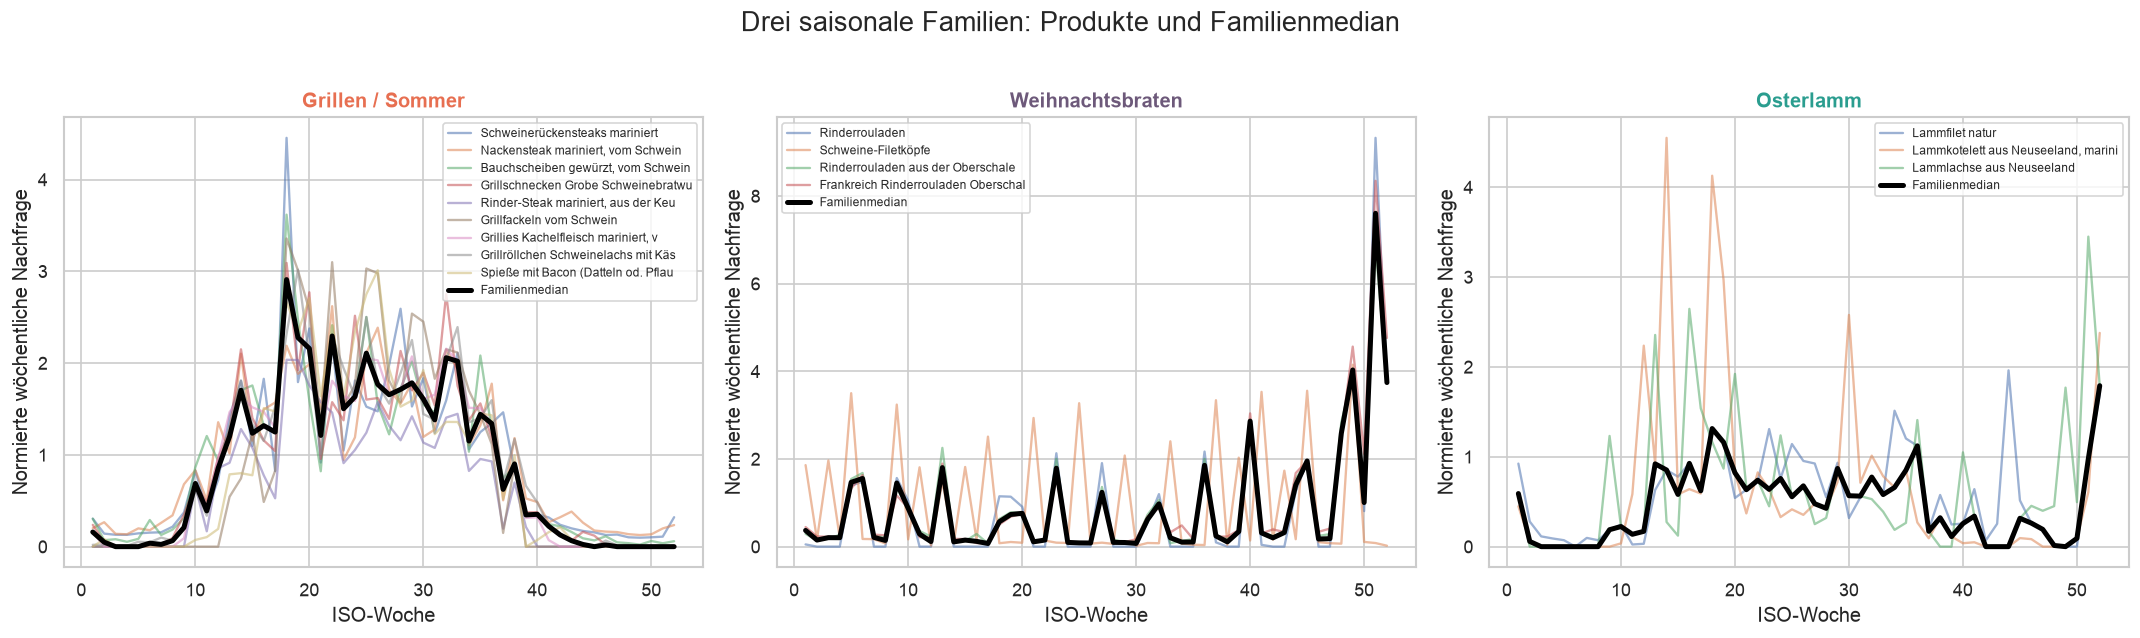

In [21]:
fig, axes = plt.subplots(
    1,
    len(PRODUCT_GROUPS),
    figsize=(18, 5.2),
    sharex=True,
    squeeze=False,
)
axes = axes.ravel()

for ax, (group_name, article_ids) in zip(axes, PRODUCT_GROUPS.items()):
    group_data = group_profiles[group_profiles.group == group_name]
    if group_data.empty:
        ax.text(0.5, 0.5, "Keine geeigneten Produkte", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(GROUP_LABELS[group_name], color=GROUP_COLORS[group_name], fontweight="bold")
        ax.set_axis_off()
        continue
    for article_id, product_data in group_data.groupby("article_id"):
        ax.plot(
            product_data.sales_week,
            product_data.profile_value,
            alpha=0.55,
            linewidth=1.4,
            label=name_lookup.get(article_id, str(article_id))[:35],
        )
    family_median = group_data.groupby("sales_week").profile_value.median()
    ax.plot(
        family_median.index,
        family_median.values,
        color="black",
        linewidth=3,
        label="Familienmedian",
    )
    ax.set_title(GROUP_LABELS[group_name], color=GROUP_COLORS[group_name], fontweight="bold")
    ax.set_xlabel("ISO-Woche")
    ax.set_ylabel("Normierte wöchentliche Nachfrage")
    ax.legend(fontsize=7, ncol=1)

fig.suptitle("Drei saisonale Familien: Produkte und Familienmedian", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

### ADI–CV² support for the seasonal families

Annual seasonality and intermittent-demand class answer different questions. The family analysis describes **when during the year** demand peaks; ADI–CV² describes **how often** demand occurs and how variable its positive amounts are at daily product-store level.

The standard cutoffs are used: ADI 1.32 and CV² 0.49. The table and stacked bars below show whether each seasonal family is mostly smooth/erratic (frequent demand) or intermittent/lumpy (sparse demand). Classification is performed before aggregation, so every observation is one product-store series.

,group,demand_class,product_store_series,products,share_pct,median_ADI,median_CV2
0,Barbecue / summer,erratic,348,7,24.2,1.185137,1.667468
1,Barbecue / summer,intermittent,14,5,1.0,5.534650,0.424937
2,Barbecue / summer,lumpy,1077,9,74.8,2.238916,1.026071
3,Barbecue / summer,smooth,1,1,0.1,1.160000,0.396514
4,Christmas roasts,erratic,3,2,0.8,1.289362,2.435226
5,Christmas roasts,intermittent,1,1,0.3,5.555556,0.479048
6,Christmas roasts,lumpy,362,4,98.9,3.033519,1.420874
7,Easter lamb,erratic,1,1,0.4,1.287535,0.941562
8,Easter lamb,intermittent,14,3,5.5,6.973299,0.440562
9,Easter lamb,lumpy,239,3,94.1,3.851695,0.791381


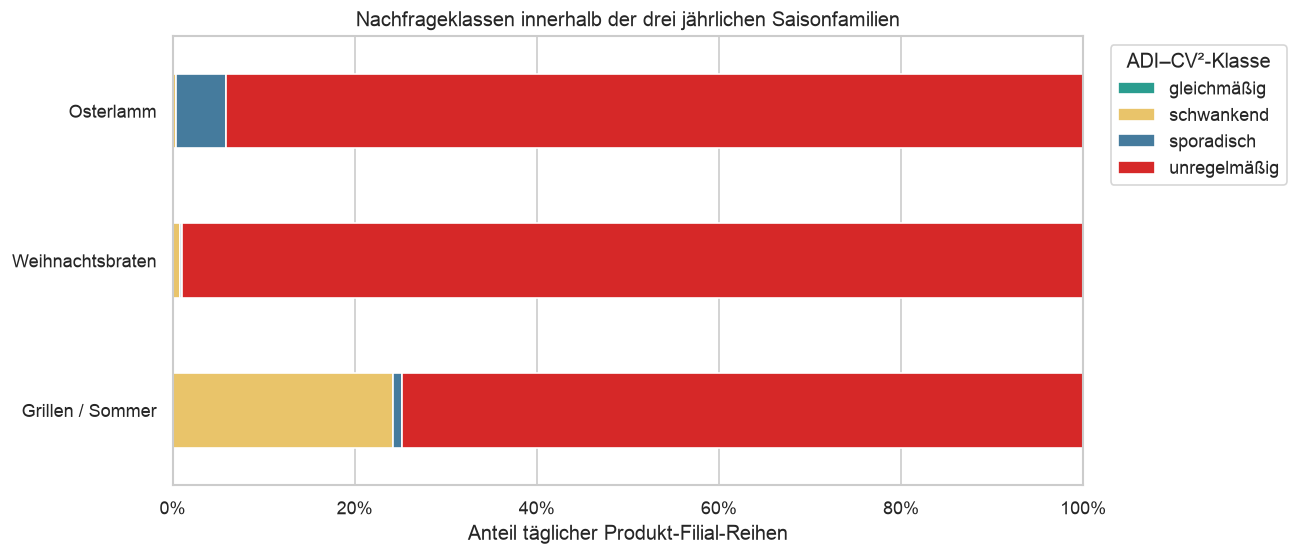

regular,smooth_or_erratic_pct
group,
Barbecue / summer,24.2
Christmas roasts,0.8
Easter lamb,0.4


In [22]:
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49
ADI_CLASS_ORDER = ["smooth", "erratic", "intermittent", "lumpy"]
ADI_CLASS_COLORS = {
    "smooth": "#2A9D8F",
    "erratic": "#E9C46A",
    "intermittent": "#457B9D",
    "lumpy": "#D62828",
}

con.execute(f"""
CREATE OR REPLACE TEMP TABLE daily_adi_cv2 AS
WITH series AS (
    SELECT
        ARTIKEL_ID AS article_id,
        MARKT_ID AS store_id,
        CASE WHEN bool_or(is_fcm) THEN 'FCM' ELSE 'Pseudo' END AS source_class,
        count(*) AS active_days,
        count_if(ABVERKAUFTE_MENGE_KG > 0) AS demand_days,
        avg(CASE WHEN ABVERKAUFTE_MENGE_KG > 0 THEN ABVERKAUFTE_MENGE_KG END) AS mean_positive,
        var_samp(CASE WHEN ABVERKAUFTE_MENGE_KG > 0 THEN ABVERKAUFTE_MENGE_KG END) AS var_positive
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active AND (is_fcm OR is_pseudo)
    GROUP BY ARTIKEL_ID, MARKT_ID
), metrics AS (
    SELECT
        *,
        active_days / nullif(demand_days, 0) AS ADI,
        CASE
            WHEN demand_days > 1 AND mean_positive > 0
            THEN var_positive / (mean_positive * mean_positive)
            WHEN demand_days = 1 THEN 0.0
        END AS CV2
    FROM series
    WHERE demand_days >= 10
)
SELECT
    *,
    CASE
        WHEN ADI < {ADI_CUTOFF} AND CV2 < {CV2_CUTOFF} THEN 'smooth'
        WHEN ADI < {ADI_CUTOFF} AND CV2 >= {CV2_CUTOFF} THEN 'erratic'
        WHEN ADI >= {ADI_CUTOFF} AND CV2 < {CV2_CUTOFF} THEN 'intermittent'
        WHEN ADI >= {ADI_CUTOFF} AND CV2 >= {CV2_CUTOFF} THEN 'lumpy'
    END AS demand_class
FROM metrics
""")

family_membership = pd.DataFrame(
    [(article_id, group_name) for article_id, group_name in group_lookup.items()],
    columns=["article_id", "group"],
)
con.register("family_membership", family_membership)
family_adi = con.execute("""
    SELECT
        f.group,
        a.demand_class,
        count(*) AS product_store_series,
        count(DISTINCT a.article_id) AS products,
        median(a.ADI) AS median_ADI,
        median(a.CV2) AS median_CV2
    FROM daily_adi_cv2 a
    JOIN family_membership f USING (article_id)
    WHERE a.demand_class IS NOT NULL
    GROUP BY f.group, a.demand_class
""").fetchdf()
family_adi["share"] = family_adi.groupby("group").product_store_series.transform(
    lambda values: values / values.sum()
)
display(
    family_adi.sort_values(["group", "demand_class"])
    .assign(share_pct=lambda x: (100 * x.share).round(1))
    [["group", "demand_class", "product_store_series", "products", "share_pct", "median_ADI", "median_CV2"]]
    .reset_index(drop=True)
)

family_adi_wide = (
    family_adi.pivot(index="group", columns="demand_class", values="share")
    .reindex(index=PRODUCT_GROUPS, columns=ADI_CLASS_ORDER)
    .fillna(0)
)
ax = family_adi_wide.rename(index=GROUP_LABELS, columns=ADI_CLASS_LABELS).plot(
    kind="barh", stacked=True, figsize=(11, 4.8),
    color=[ADI_CLASS_COLORS[name] for name in ADI_CLASS_ORDER],
)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_xlabel("Anteil täglicher Produkt-Filial-Reihen")
ax.set_ylabel("")
ax.set_title("Nachfrageklassen innerhalb der drei jährlichen Saisonfamilien")
ax.legend(title="ADI–CV²-Klasse", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

regular_share = family_adi.assign(
    regular=lambda x: x.demand_class.isin(["smooth", "erratic"])
).groupby(["group", "regular"]).product_store_series.sum().unstack(fill_value=0)
regular_share["smooth_or_erratic_share"] = (
    regular_share.get(True, 0) / regular_share.sum(axis=1)
)
display(
    regular_share[["smooth_or_erratic_share"]]
    .assign(smooth_or_erratic_pct=lambda x: (100 * x.smooth_or_erratic_share).round(1))
    [["smooth_or_erratic_pct"]]
)

### Easter-aligned lamb demand

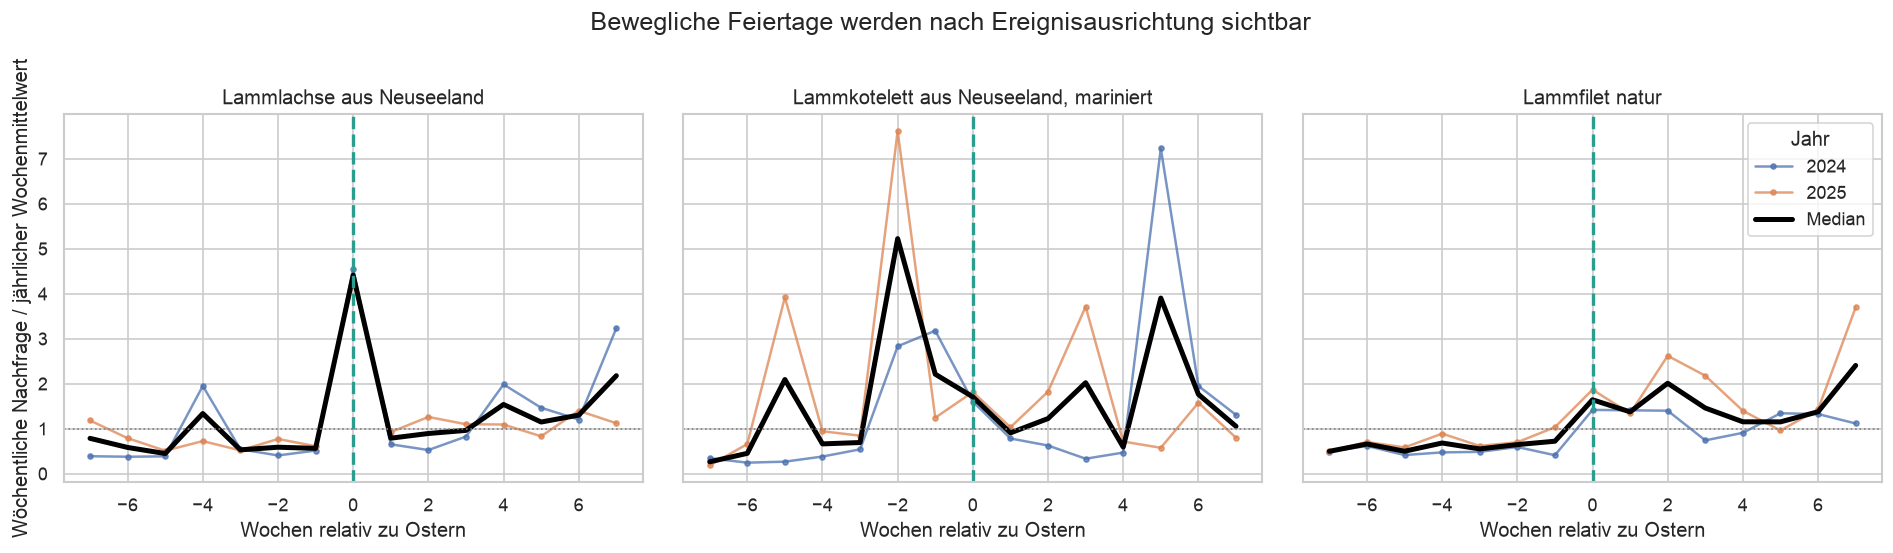

In [23]:
easter_aligned = con.execute(f"""
WITH easter(sales_year, easter_date) AS (
    VALUES
        (2024, DATE '2024-03-31'),
        (2025, DATE '2025-04-20')
),
weekly AS (
    SELECT
        ARTIKEL_ID AS article_id,
        any_value(ARTIKEL_BEZ) AS product_name,
        year(DATE::DATE) AS sales_year,
        date_trunc('week', DATE::DATE)::DATE AS week_date,
        sum(ABVERKAUFTE_MENGE_KG) AS demand_kg
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active
      AND ARTIKEL_ID IN (317043, 317033, 317004)
      AND year(DATE::DATE) IN ({FULL_YEARS_SQL})
    GROUP BY ARTIKEL_ID, year(DATE::DATE), date_trunc('week', DATE::DATE)
),
normalized AS (
    SELECT
        *,
        demand_kg / nullif(avg(demand_kg) OVER (
            PARTITION BY article_id, sales_year
        ), 0) AS demand_vs_annual_week
    FROM weekly
)
SELECT
    n.*,
    date_diff(
        'week', date_trunc('week', e.easter_date), n.week_date
    ) AS weeks_from_easter
FROM normalized n
JOIN easter e USING (sales_year)
WHERE abs(date_diff(
    'week', date_trunc('week', e.easter_date), n.week_date
)) <= 7
ORDER BY article_id, sales_year, weeks_from_easter
""").fetchdf()

easter_ids = [317043, 317033, 317004]
fig, axes = plt.subplots(1, len(easter_ids), figsize=(16, 4.5), sharey=True)
for ax, article_id in zip(axes, easter_ids):
    product_data = easter_aligned[easter_aligned.article_id == article_id]
    if product_data.empty:
        ax.text(0.5, 0.5, "Keine geeigneten Daten", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue
    for sales_year, year_data in product_data.groupby("sales_year"):
        ax.plot(
            year_data.weeks_from_easter,
            year_data.demand_vs_annual_week,
            marker="o",
            markersize=3,
            linewidth=1.5,
            alpha=0.75,
            label=str(sales_year),
        )
    median_profile = product_data.groupby("weeks_from_easter").demand_vs_annual_week.median()
    ax.plot(median_profile.index, median_profile.values, color="black", linewidth=3, label="Median")
    ax.axvline(0, color=GROUP_COLORS["Easter lamb"], linestyle="--", linewidth=2)
    ax.axhline(1, color="0.5", linestyle=":", linewidth=1)
    ax.set_title(product_data.product_name.iloc[0])
    ax.set_xlabel("Wochen relativ zu Ostern")
axes[0].set_ylabel("Wöchentliche Nachfrage / jährlicher Wochenmittelwert")
next((ax for ax in reversed(axes) if ax.axison), axes[-1]).legend(title="Jahr")
fig.suptitle("Bewegliche Feiertage werden nach Ereignisausrichtung sichtbar", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 5. Within-family and between-family connections

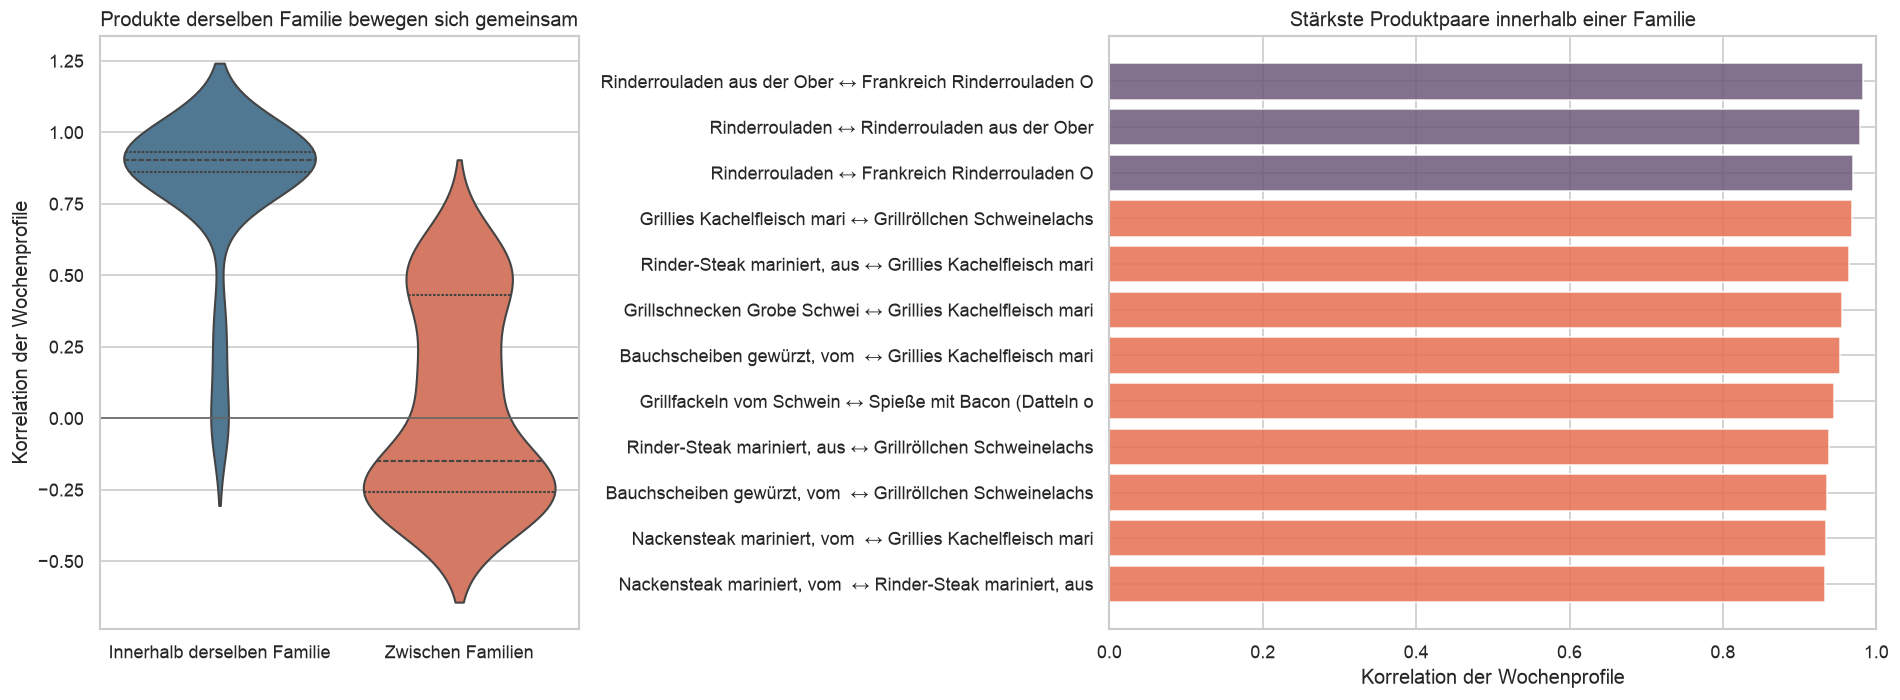

In [24]:
selected_profile_matrix = group_profiles.pivot(
    index="sales_week", columns="article_id", values="profile_value"
)
selected_product_corr = selected_profile_matrix.corr()

pair_rows = []
for position, article_a in enumerate(selected_product_corr.index):
    for article_b in selected_product_corr.columns[position + 1:]:
        group_a = group_lookup[article_a]
        group_b = group_lookup[article_b]
        pair_rows.append({
            "product_a": name_lookup.get(article_a, str(article_a)),
            "product_b": name_lookup.get(article_b, str(article_b)),
            "group_a": group_a,
            "group_b": group_b,
            "comparison": "Within the same family" if group_a == group_b else "Across families",
            "correlation": selected_product_corr.at[article_a, article_b],
        })
family_pairs = pd.DataFrame(pair_rows).dropna(subset=["correlation"])
family_pairs["comparison_label"] = family_pairs["comparison"].map({
    "Within the same family": "Innerhalb derselben Familie",
    "Across families": "Zwischen Familien",
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.6]})
sns.violinplot(
    data=family_pairs,
    x="comparison_label",
    y="correlation",
    hue="comparison_label",
    palette=["#457B9D", "#E76F51"],
    inner="quartile",
    legend=False,
    ax=axes[0],
)
axes[0].axhline(0, color="0.4", linewidth=1)
axes[0].set_xlabel("")
axes[0].set_ylabel("Korrelation der Wochenprofile")
axes[0].set_title("Produkte derselben Familie bewegen sich gemeinsam")

strongest_within = (
    family_pairs[family_pairs.comparison == "Within the same family"]
    .nlargest(12, "correlation")
    .copy()
)
strongest_within["pair"] = (
    strongest_within.product_a.str.slice(0, 27)
    + " ↔ "
    + strongest_within.product_b.str.slice(0, 27)
)
strongest_within = strongest_within.sort_values("correlation")
axes[1].barh(
    strongest_within["pair"],
    strongest_within.correlation,
    color=[GROUP_COLORS[group] for group in strongest_within.group_a],
    alpha=0.85,
)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Korrelation der Wochenprofile")
axes[1].set_title("Stärkste Produktpaare innerhalb einer Familie")

fig.tight_layout()
plt.show()


## 6. FCM cross-store relationships

FCM starts in April 2025, so it cannot yet be judged by the complete-year 2024–2025 repetition rule. This section asks a narrower question: **do FCM stores rise and fall together over their shared observed calendar weeks?**

For every eligible product-store series, missing weeks between its first and last observed week are filled with zero before normalization. Weeks before launch or after the final observation are not fabricated. At least 12 observed weeks are required per store and at least 10 stores per displayed product.

Correlation can reflect common promotions, assortment rollout, or genuine seasonality; it is evidence of synchronization, not causality. Direct FCM–Pseudo product connections are kept in `01_05_fcm_pseudo_correlations.ipynb`.

In [25]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE recent_weekly AS
SELECT
    ARTIKEL_ID AS article_id,
    any_value(ARTIKEL_BEZ) AS product_name,
    CASE
        WHEN bool_or(is_fcm) THEN 'FCM'
        WHEN bool_or(is_pseudo) THEN 'Pseudo'
    END AS source_class,
    MARKT_ID AS store_id,
    date_trunc('week', DATE::DATE)::DATE AS week_date,
    sum(ABVERKAUFTE_MENGE_KG) AS demand_kg
FROM read_parquet('{DATA_GLOB}')
WHERE is_active
  AND DATE::DATE >= DATE '{RECENT_START}'
  AND (is_fcm OR is_pseudo)
GROUP BY ARTIKEL_ID, MARKT_ID, date_trunc('week', DATE::DATE)
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE recent_eligible AS
SELECT
    article_id,
    source_class,
    store_id,
    any_value(product_name) AS product_name,
    min(week_date) AS first_week,
    max(week_date) AS last_week
FROM recent_weekly
GROUP BY article_id, source_class, store_id
HAVING count(*) >= 12 AND sum(demand_kg) > 0
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE recent_normalized AS
WITH grid AS (
    SELECT
        e.article_id,
        e.product_name,
        e.source_class,
        e.store_id,
        generated.week_date::DATE AS week_date
    FROM recent_eligible e,
    LATERAL generate_series(
        e.first_week::TIMESTAMP,
        e.last_week::TIMESTAMP,
        INTERVAL 7 DAY
    ) generated(week_date)
),
filled AS (
    SELECT
        g.*,
        coalesce(w.demand_kg, 0.0) AS demand_kg
    FROM grid g
    LEFT JOIN recent_weekly w
      USING (article_id, source_class, store_id, week_date)
),
with_mean AS (
    SELECT
        *,
        avg(demand_kg) OVER (
            PARTITION BY article_id, source_class, store_id
        ) AS mean_weekly_demand
    FROM filled
)
SELECT
    article_id,
    product_name,
    source_class,
    store_id,
    week_date,
    demand_kg / nullif(mean_weekly_demand, 0) AS normalized_demand
FROM with_mean
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE recent_product_profile AS
SELECT
    article_id,
    any_value(product_name) AS product_name,
    source_class,
    week_date,
    median(normalized_demand) AS profile_value,
    count(DISTINCT store_id) AS stores
FROM recent_normalized
GROUP BY article_id, source_class, week_date
""")

recent_info = con.execute("""
    SELECT
        article_id,
        any_value(product_name) AS product_name,
        source_class,
        max(stores) AS eligible_stores,
        count(*) AS profile_weeks,
        min(week_date) AS first_week,
        max(week_date) AS last_week
    FROM recent_product_profile
    GROUP BY article_id, source_class
""").fetchdf()

display(
    recent_info[recent_info.source_class == "FCM"]
    .sort_values(["profile_weeks", "eligible_stores"], ascending=False)
    .reset_index(drop=True)
)

,article_id,product_name,source_class,eligible_stores,profile_weeks,first_week,last_week
0,1382768,Fleischkäse ofengebacken,FCM,184,67,2025-04-14,2026-07-20
1,1382767,Fleischwurst ohne Knoblauch,FCM,152,64,2025-05-05,2026-07-20
2,1382766,Fleischwurst mit Knoblauch,FCM,150,64,2025-05-05,2026-07-20
3,1382863,Rostbratwurst (eigene Herstellung),FCM,35,64,2025-05-05,2026-07-20
4,1382764,Braunschweiger grobe Streichmettwurst,FCM,189,62,2025-05-19,2026-07-20
5,1376860,Pfefferbeißer,FCM,177,61,2025-05-26,2026-07-20
6,1382788,"Goldmarie Friesen Bratwurst, gebrüht",FCM,167,61,2025-05-26,2026-07-20
7,1382765,Braunschweiger feine Streichmettwurst,FCM,189,60,2025-06-02,2026-07-20
8,1382858,Goldmarie Krakauer,FCM,134,57,2025-06-23,2026-07-20
9,1382777,Goldmarie gekochte Schweinemettwurst,FCM,179,53,2025-07-21,2026-07-20


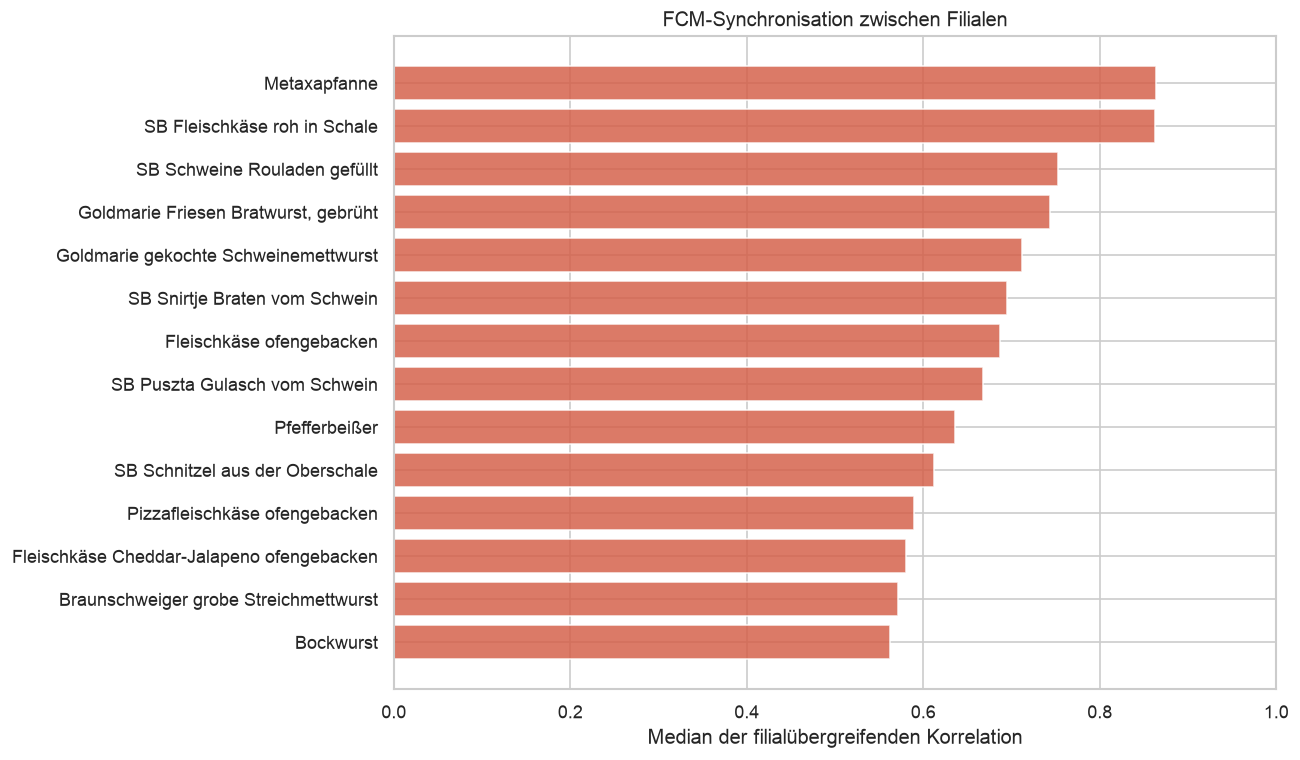

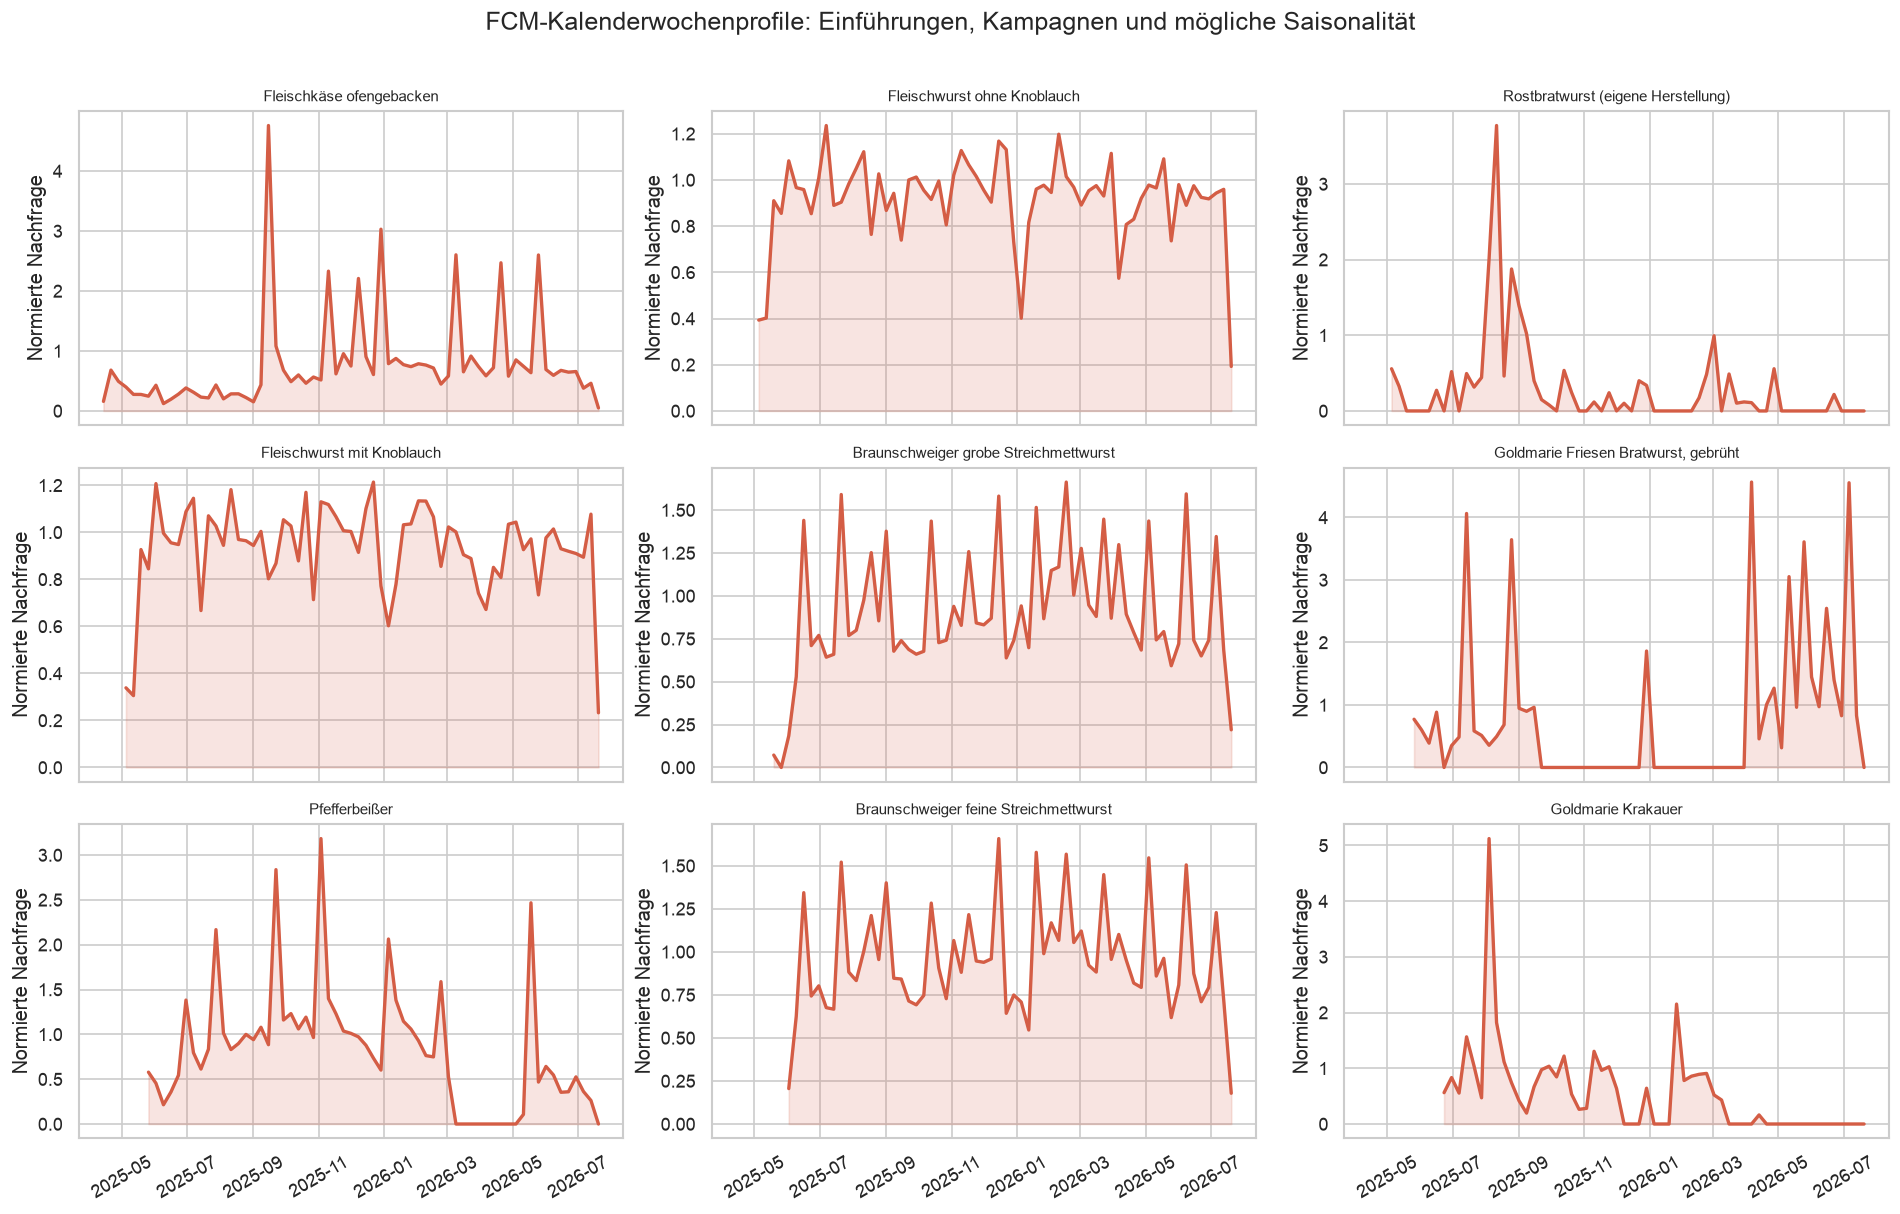

In [26]:
fcm_store_agreement = con.execute("""
WITH store_correlations AS (
    SELECT
        n.article_id,
        any_value(n.product_name) AS product_name,
        n.store_id,
        corr(n.normalized_demand, p.profile_value) AS store_correlation,
        count(*) AS compared_weeks
    FROM recent_normalized n
    JOIN recent_product_profile p
      USING (article_id, source_class, week_date)
    WHERE n.source_class = 'FCM'
    GROUP BY n.article_id, n.store_id
    HAVING count(*) >= 12
)
SELECT
    article_id,
    any_value(product_name) AS product_name,
    count(*) AS eligible_stores,
    median(compared_weeks) AS median_weeks,
    median(store_correlation) AS median_store_correlation
FROM store_correlations
GROUP BY article_id
HAVING count(*) >= 10
ORDER BY median_store_correlation DESC
""").fetchdf()

fcm_profiles = con.execute("""
    SELECT article_id, product_name, week_date, profile_value
    FROM recent_product_profile
    WHERE source_class = 'FCM'
""").fetchdf()

top_fcm = fcm_store_agreement.head(14).sort_values("median_store_correlation")
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(
    top_fcm.product_name,
    top_fcm.median_store_correlation,
    color=SOURCE_COLORS["FCM"],
    alpha=0.82,
)
ax.set_xlim(0, 1)
ax.set_xlabel("Median der filialübergreifenden Korrelation")
ax.set_title("FCM-Synchronisation zwischen Filialen")
fig.tight_layout()
plt.show()

longest_fcm_ids = (
    recent_info.query("source_class == 'FCM' and eligible_stores >= 10")
    .nlargest(9, "profile_weeks")
    .article_id
    .tolist()
)
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for ax, article_id in zip(axes.flat, longest_fcm_ids):
    product_data = fcm_profiles[fcm_profiles.article_id == article_id].sort_values("week_date")
    ax.plot(product_data.week_date, product_data.profile_value, color=SOURCE_COLORS["FCM"], linewidth=2)
    ax.fill_between(
        product_data.week_date,
        0,
        product_data.profile_value,
        color=SOURCE_COLORS["FCM"],
        alpha=0.16,
    )
    ax.set_title(product_data.product_name.iloc[0], fontsize=9)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Normierte Nachfrage")
for ax in axes.flat[len(longest_fcm_ids):]:
    ax.set_visible(False)
fig.suptitle("FCM-Kalenderwochenprofile: Einführungen, Kampagnen und mögliche Saisonalität", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()


### ADI–CV² support for FCM cross-store agreement

The next view joins each FCM product's cross-store correlation to the daily ADI–CV² classifications of its store series. This checks whether apparent synchronization is concentrated in frequently selling series or is being driven by sparse/lumpy demand.

,article_id,product_name,eligible_stores,median_store_correlation,median_ADI,median_CV2,dominant_demand_class,smooth_share,erratic_share,intermittent_share,lumpy_share
0,1425927,Metaxapfanne,53,0.863166,4.888889,0.473105,intermittent,0.000000,0.000000,0.547170,0.452830
1,1406063,SB Fleischkäse roh in Schale,186,0.862489,2.837079,0.772636,lumpy,0.000000,0.000000,0.096774,0.903226
2,1406593,SB Schweine Rouladen gefüllt,23,0.752529,8.923077,0.308633,intermittent,0.000000,0.000000,1.000000,0.000000
3,1382788,"Goldmarie Friesen Bratwurst, gebrüht",167,0.743785,5.089552,0.669454,lumpy,0.000000,0.000000,0.125000,0.875000
4,1382777,Goldmarie gekochte Schweinemettwurst,179,0.712223,1.561856,0.531578,lumpy,0.116667,0.172222,0.238889,0.472222
5,1406587,SB Snirtje Braten vom Schwein,82,0.694485,6.621622,0.259933,intermittent,0.000000,0.000000,0.951220,0.048780
6,1382768,Fleischkäse ofengebacken,184,0.686525,2.000000,1.261357,lumpy,0.000000,0.108696,0.010870,0.880435
7,1406590,SB Puszta Gulasch vom Schwein,130,0.667228,6.569498,0.224804,intermittent,0.000000,0.000000,0.976923,0.023077
8,1376860,Pfefferbeißer,177,0.636142,2.722222,0.588645,lumpy,0.005650,0.005650,0.175141,0.813559
9,1402822,SB Schnitzel aus der Oberschale,23,0.612360,8.428571,0.233436,intermittent,0.000000,0.000000,0.956522,0.043478


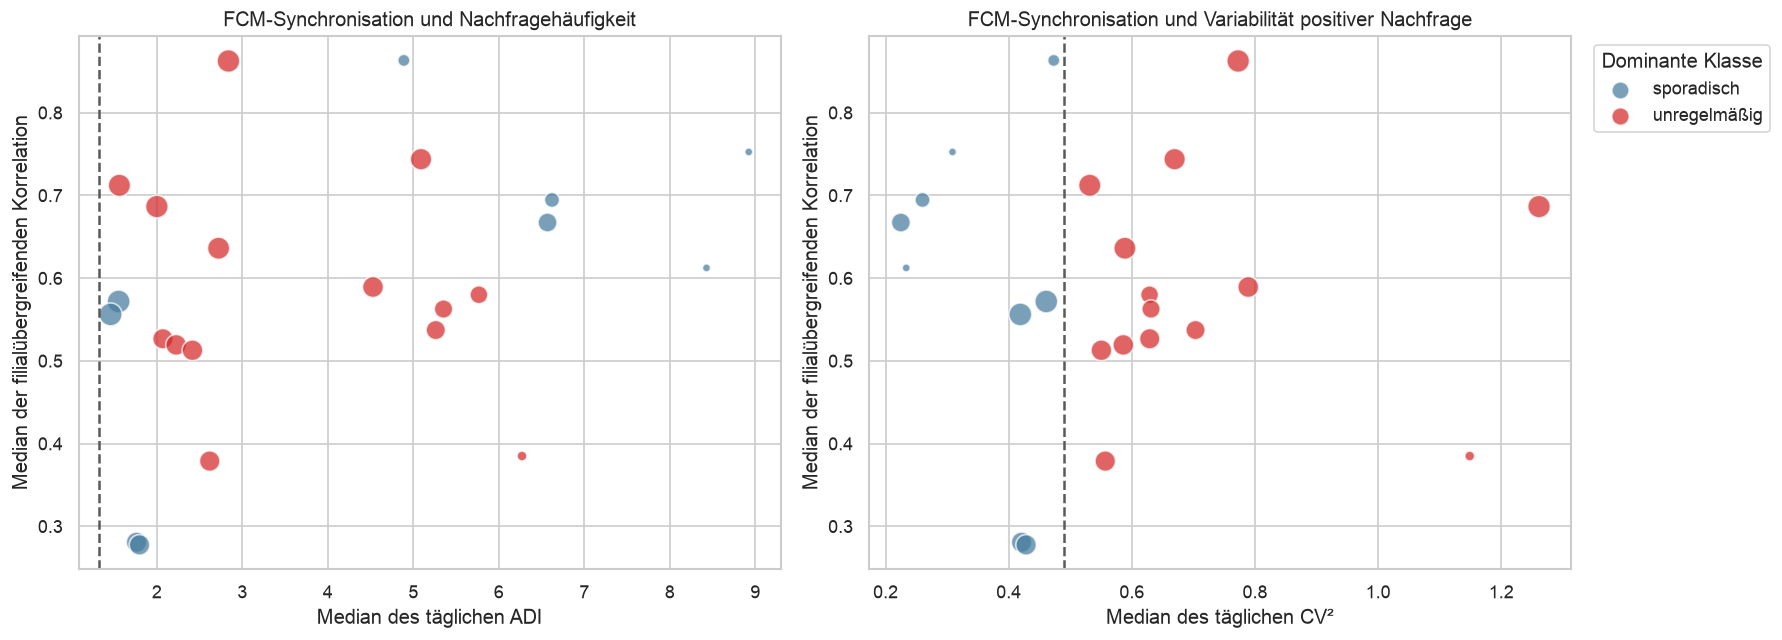

In [27]:
fcm_adi_product = con.execute("""
    SELECT
        article_id,
        median(ADI) AS median_ADI,
        median(CV2) AS median_CV2,
        count(*) AS classified_store_series,
        avg((demand_class = 'smooth')::INT) AS smooth_share,
        avg((demand_class = 'erratic')::INT) AS erratic_share,
        avg((demand_class = 'intermittent')::INT) AS intermittent_share,
        avg((demand_class = 'lumpy')::INT) AS lumpy_share,
        mode(demand_class) AS dominant_demand_class
    FROM daily_adi_cv2
    WHERE source_class = 'FCM' AND demand_class IS NOT NULL
    GROUP BY article_id
""").fetchdf()

fcm_store_adi = fcm_store_agreement.merge(
    fcm_adi_product, on="article_id", how="left", validate="one_to_one"
)
display(
    fcm_store_adi[[
        "article_id", "product_name", "eligible_stores",
        "median_store_correlation", "median_ADI", "median_CV2",
        "dominant_demand_class", "smooth_share", "erratic_share",
        "intermittent_share", "lumpy_share",
    ]].sort_values("median_store_correlation", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for demand_class, group in fcm_store_adi.groupby("dominant_demand_class"):
    axes[0].scatter(
        group.median_ADI,
        group.median_store_correlation,
        s=np.clip(group.eligible_stores, 10, 190),
        alpha=0.72,
        color=ADI_CLASS_COLORS[demand_class],
        label=ADI_CLASS_LABELS[demand_class],
        edgecolor="white",
    )
    axes[1].scatter(
        group.median_CV2,
        group.median_store_correlation,
        s=np.clip(group.eligible_stores, 10, 190),
        alpha=0.72,
        color=ADI_CLASS_COLORS[demand_class],
        label=ADI_CLASS_LABELS[demand_class],
        edgecolor="white",
    )
axes[0].axvline(ADI_CUTOFF, color="0.35", linestyle="--")
axes[1].axvline(CV2_CUTOFF, color="0.35", linestyle="--")
axes[0].set(xlabel="Median des täglichen ADI", ylabel="Median der filialübergreifenden Korrelation")
axes[1].set(xlabel="Median des täglichen CV²", ylabel="Median der filialübergreifenden Korrelation")
axes[0].set_title("FCM-Synchronisation und Nachfragehäufigkeit")
axes[1].set_title("FCM-Synchronisation und Variabilität positiver Nachfrage")
axes[1].legend(title="Dominante Klasse", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

### Provisional FCM seasonal-family assignment

Each sufficiently observed FCM product is compared with the **three repeated 2024–2025 family profiles** after mapping its calendar dates to ISO week. An assignment is **strong** when the best correlation is at least 0.60 and clearly exceeds the runner-up; it is **tentative** from 0.30 with a smaller but meaningful lead. Everything else remains unassigned. These labels describe profile similarity, not yet proven long-run annual repetition.

,article_id,FCM product,assigned_group,confidence,best_matching_group,best_correlation,runner_up,runner_up_correlation,margin,compared_weeks
0,1382788,"Goldmarie Friesen Bratwurst, gebrüht",Barbecue / summer,Tentative,Barbecue / summer,0.533529,Easter lamb,0.359323,0.174206,52
1,1413151,Fleischkäse Cheddar-Jalapeno ofengebacken,Christmas roasts,Tentative,Christmas roasts,0.526096,Easter lamb,0.418638,0.107458,33
2,1413121,Schweinebraten-Aufschnitt Spießbraten Art,Christmas roasts,Tentative,Christmas roasts,0.367943,Easter lamb,-0.038860,0.406802,27
3,1406587,SB Snirtje Braten vom Schwein,Christmas roasts,Tentative,Christmas roasts,0.352508,Easter lamb,-0.496236,0.848745,44
4,1413120,Schweinebraten-Aufschnitt Gyros Art,Christmas roasts,Tentative,Christmas roasts,0.349440,Easter lamb,-0.121051,0.470491,27
5,1382766,Fleischwurst mit Knoblauch,Christmas roasts,Tentative,Christmas roasts,0.314163,Easter lamb,-0.071577,0.385740,52
6,1382863,Rostbratwurst (eigene Herstellung),Barbecue / summer,Tentative,Barbecue / summer,0.310013,Easter lamb,0.202126,0.107887,52
7,1382767,Fleischwurst ohne Knoblauch,Christmas roasts,Tentative,Christmas roasts,0.306282,Easter lamb,-0.016376,0.322657,52
8,1406590,SB Puszta Gulasch vom Schwein,Unassigned,Unassigned,Christmas roasts,0.296694,Easter lamb,-0.492969,0.789663,44
9,1413118,Schweinebraten-Aufschnitt mit Pfeffer,Unassigned,Unassigned,Christmas roasts,0.286673,Easter lamb,-0.053372,0.340045,27


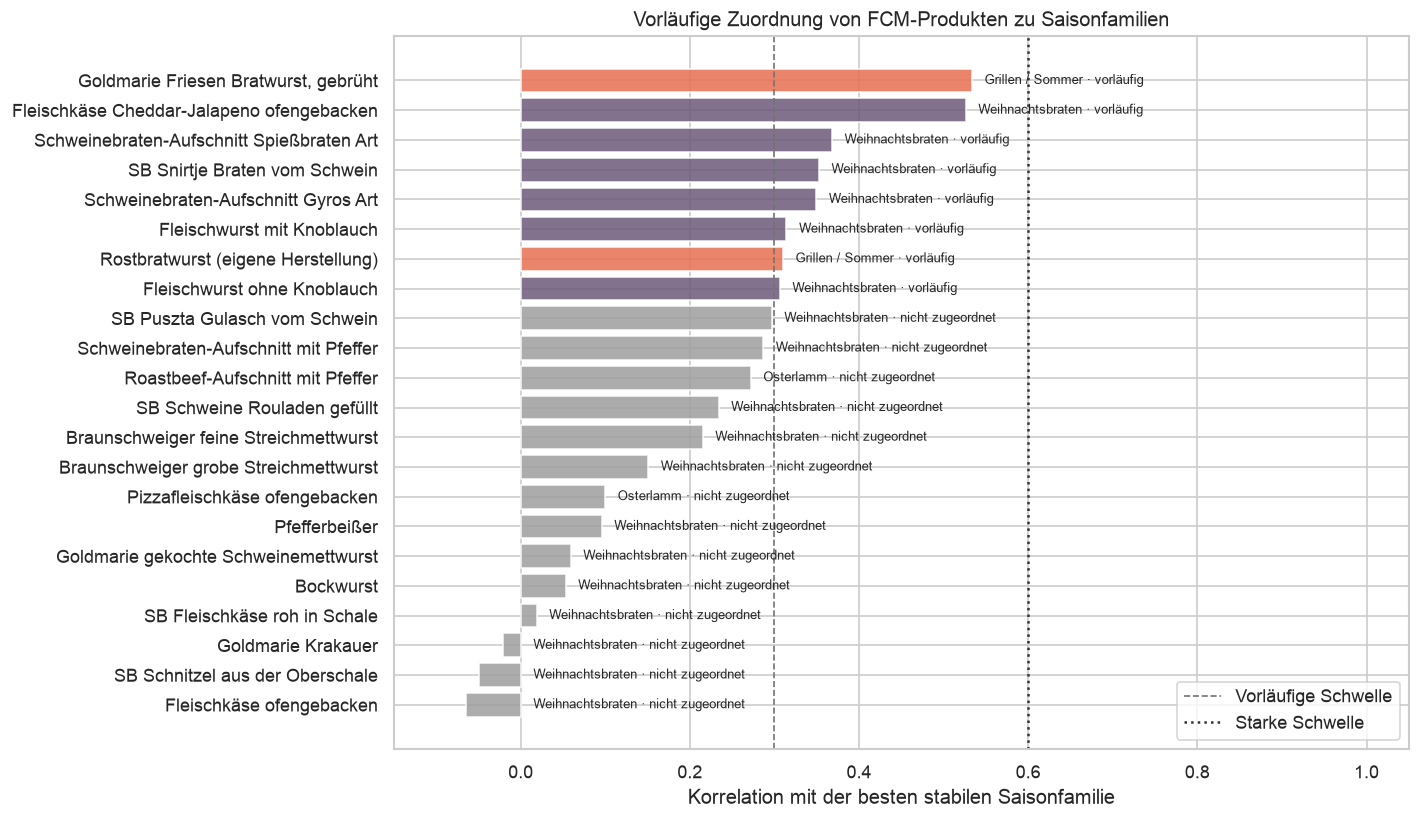

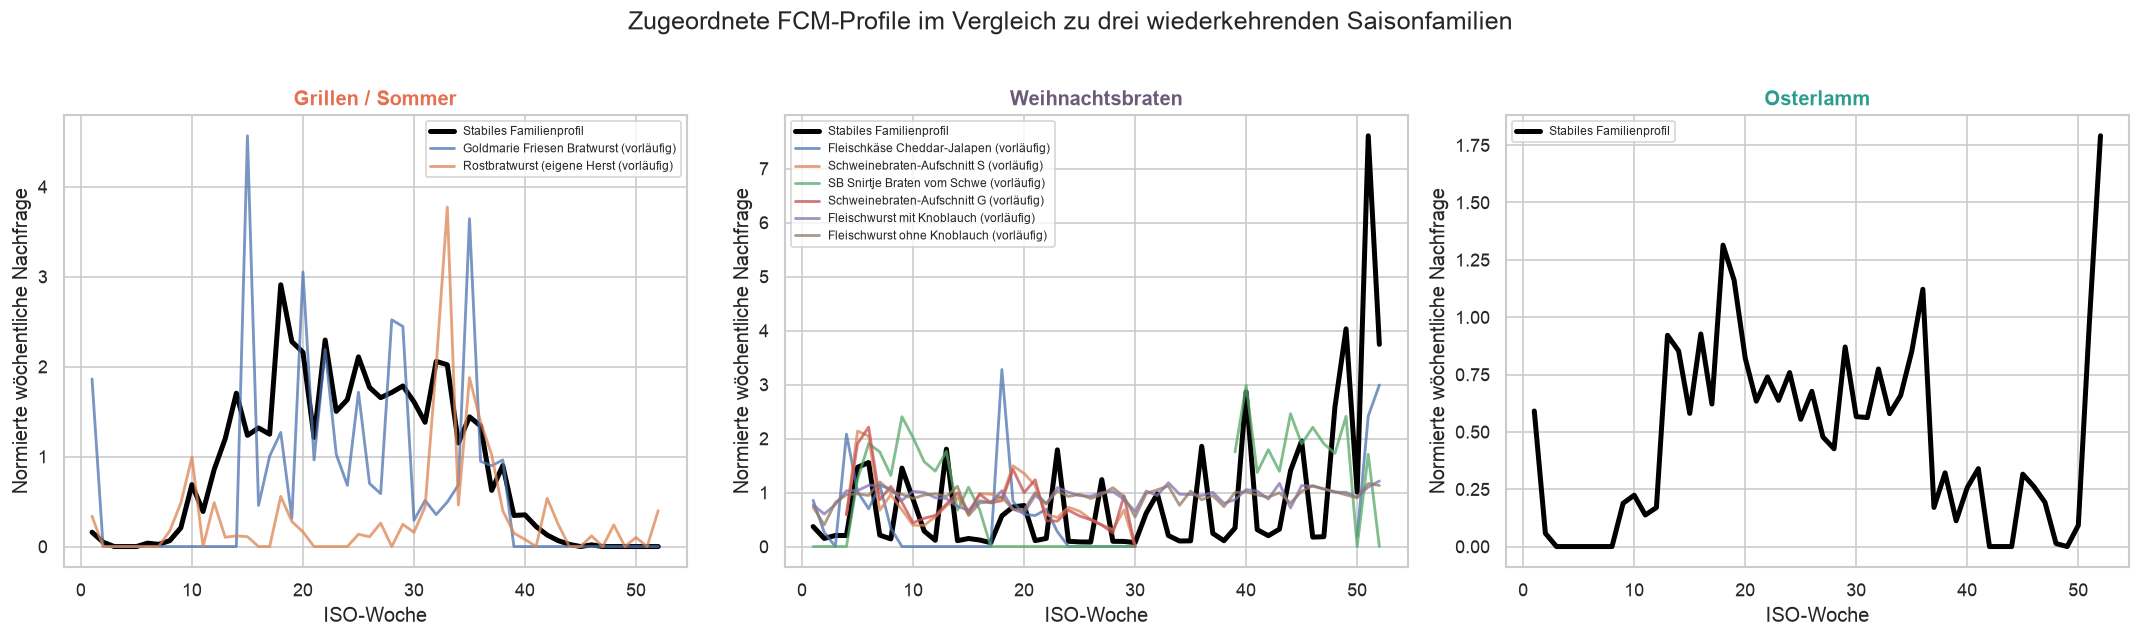

In [28]:
stable_group_prototypes = (
    group_profiles.groupby(["group", "sales_week"], as_index=False)
    .profile_value.median()
)

fcm_seasonal_profiles = fcm_profiles.copy()
fcm_seasonal_profiles["week_date"] = pd.to_datetime(fcm_seasonal_profiles.week_date)
fcm_seasonal_profiles["sales_week"] = (
    fcm_seasonal_profiles.week_date.dt.isocalendar().week.astype(int)
)
fcm_seasonal_profiles = (
    fcm_seasonal_profiles.groupby(
        ["article_id", "product_name", "sales_week"], as_index=False
    ).profile_value.mean()
)

eligible_fcm_assignment = recent_info.query(
    "source_class == 'FCM' and eligible_stores >= 10 and profile_weeks >= 26"
)
assignment_rows = []
for product in eligible_fcm_assignment.itertuples():
    product_curve = fcm_seasonal_profiles[
        fcm_seasonal_profiles.article_id == product.article_id
    ][["sales_week", "profile_value"]]
    correlations = []
    for group_name, group_curve in stable_group_prototypes.groupby("group"):
        comparison = product_curve.merge(
            group_curve[["sales_week", "profile_value"]],
            on="sales_week",
            suffixes=("_fcm", "_group"),
        )
        correlation = comparison.profile_value_fcm.corr(comparison.profile_value_group)
        correlations.append((group_name, correlation, len(comparison)))

    correlations.sort(key=lambda value: value[1], reverse=True)
    best_group, best_correlation, compared_weeks = correlations[0]
    second_group, second_correlation, _ = correlations[1]
    margin = best_correlation - second_correlation

    if best_correlation >= 0.60 and margin >= 0.10:
        confidence = "Strong"
        assigned_group = best_group
    elif best_correlation >= 0.30 and margin >= 0.05:
        confidence = "Tentative"
        assigned_group = best_group
    else:
        confidence = "Unassigned"
        assigned_group = "Unassigned"

    assignment_rows.append({
        "article_id": product.article_id,
        "FCM product": product.product_name,
        "assigned_group": assigned_group,
        "confidence": confidence,
        "best_matching_group": best_group,
        "best_correlation": best_correlation,
        "runner_up": second_group,
        "runner_up_correlation": second_correlation,
        "margin": margin,
        "compared_weeks": compared_weeks,
    })

fcm_assignments = pd.DataFrame(assignment_rows).sort_values("best_correlation", ascending=False)
display(fcm_assignments.reset_index(drop=True))

plot_assignments = fcm_assignments.sort_values("best_correlation")
bar_colors = [
    GROUP_COLORS.get(group, "#9E9E9E")
    for group in plot_assignments.assigned_group
]
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    plot_assignments["FCM product"],
    plot_assignments.best_correlation,
    color=bar_colors,
    alpha=0.85,
)
for y, row in enumerate(plot_assignments.itertuples()):
    ax.text(
        max(row.best_correlation, 0) + 0.015,
        y,
        f"{GROUP_LABELS[row.best_matching_group]} · {CONFIDENCE_LABELS[row.confidence]}",
        va="center",
        fontsize=8,
    )
ax.axvline(0.30, color="0.45", linestyle="--", linewidth=1, label="Vorläufige Schwelle")
ax.axvline(0.60, color="0.2", linestyle=":", linewidth=1.5, label="Starke Schwelle")
ax.set_xlim(min(-0.15, plot_assignments.best_correlation.min() - 0.05), 1.05)
ax.set_xlabel("Korrelation mit der besten stabilen Saisonfamilie")
ax.set_title("Vorläufige Zuordnung von FCM-Produkten zu Saisonfamilien")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    1,
    len(PRODUCT_GROUPS),
    figsize=(18, 5.2),
    sharex=True,
    squeeze=False,
)
axes = axes.ravel()
week_axis = pd.Index(range(1, 53), name="sales_week")
for ax, group_name in zip(axes, PRODUCT_GROUPS):
    prototype = (
        stable_group_prototypes[stable_group_prototypes.group == group_name]
        .set_index("sales_week")
        .profile_value
        .reindex(week_axis)
    )
    ax.plot(week_axis, prototype, color="black", linewidth=3, label="Stabiles Familienprofil")
    assigned_products = fcm_assignments[
        fcm_assignments.assigned_group == group_name
    ]
    for _, product in assigned_products.iterrows():
        curve = (
            fcm_seasonal_profiles[fcm_seasonal_profiles.article_id == product["article_id"]]
            .set_index("sales_week")
            .profile_value
            .reindex(week_axis)
        )
        ax.plot(
            week_axis,
            curve,
            linewidth=1.7,
            alpha=0.75,
            label=f"{product['FCM product'][:27]} ({CONFIDENCE_LABELS[product['confidence']]})",
        )
    ax.set_title(GROUP_LABELS[group_name], color=GROUP_COLORS[group_name], fontweight="bold")
    ax.set_ylabel("Normierte wöchentliche Nachfrage")
    ax.legend(fontsize=7)
for ax in axes:
    ax.set_xlabel("ISO-Woche")
fig.suptitle("Zugeordnete FCM-Profile im Vergleich zu drei wiederkehrenden Saisonfamilien", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()


### Where the FCM–Pseudo connection analysis moved

Pairwise FCM–Pseudo correlations were removed from this notebook so that annual family construction and cross-store synchronization remain conceptually separate. The dedicated notebook `01_05_fcm_pseudo_correlations.ipynb` contains the exploratory pair matrix, the controlling-team mapping audit, mapped-versus-unmapped comparisons, and ADI–CV² support.

## 7. Products without clear annual connections

,article_id,product_name,source_class,eligible_stores,median_store_correlation,max_abs_product_correlation,median_year_correlation,seasonal_cv
0,1215026,HofWerte Hüftsteak vom Rind,Pseudo,61,0.193293,0.437331,-0.067290,1.013776
1,1215019,HofWerte Rinderbraten Keule,Pseudo,24,0.215719,0.438565,0.149043,1.005882
2,990503,GV Schweine Lachs,Pseudo,46,0.251741,0.461262,0.191971,0.635282
3,990518,GV Nacken ohne Knochen,Pseudo,43,0.233423,0.481968,-0.001693,0.586116
4,1103386,Hofwerte Nacken ohne Knochen vom Schwein,Pseudo,91,0.227510,0.500785,0.039541,0.363791
5,1103380,Hofwerte Oberschalenschnitzel vom Schwein,Pseudo,105,0.505139,0.327513,-0.100647,0.418547
6,317229,Gewürze,Pseudo,27,0.205611,0.514162,0.251820,0.535878
7,329470,Grobe Bratwurst im Saitling vom Schwein,Pseudo,71,0.477908,0.383128,-0.087723,2.722199
8,1101181,Hofwerte Nacken ohne Knochen vom Schwein,Pseudo,21,0.433875,0.412236,-0.068306,0.359376
9,316642,Tartar vom Rind,Pseudo,134,0.187952,0.548914,0.572330,0.121035


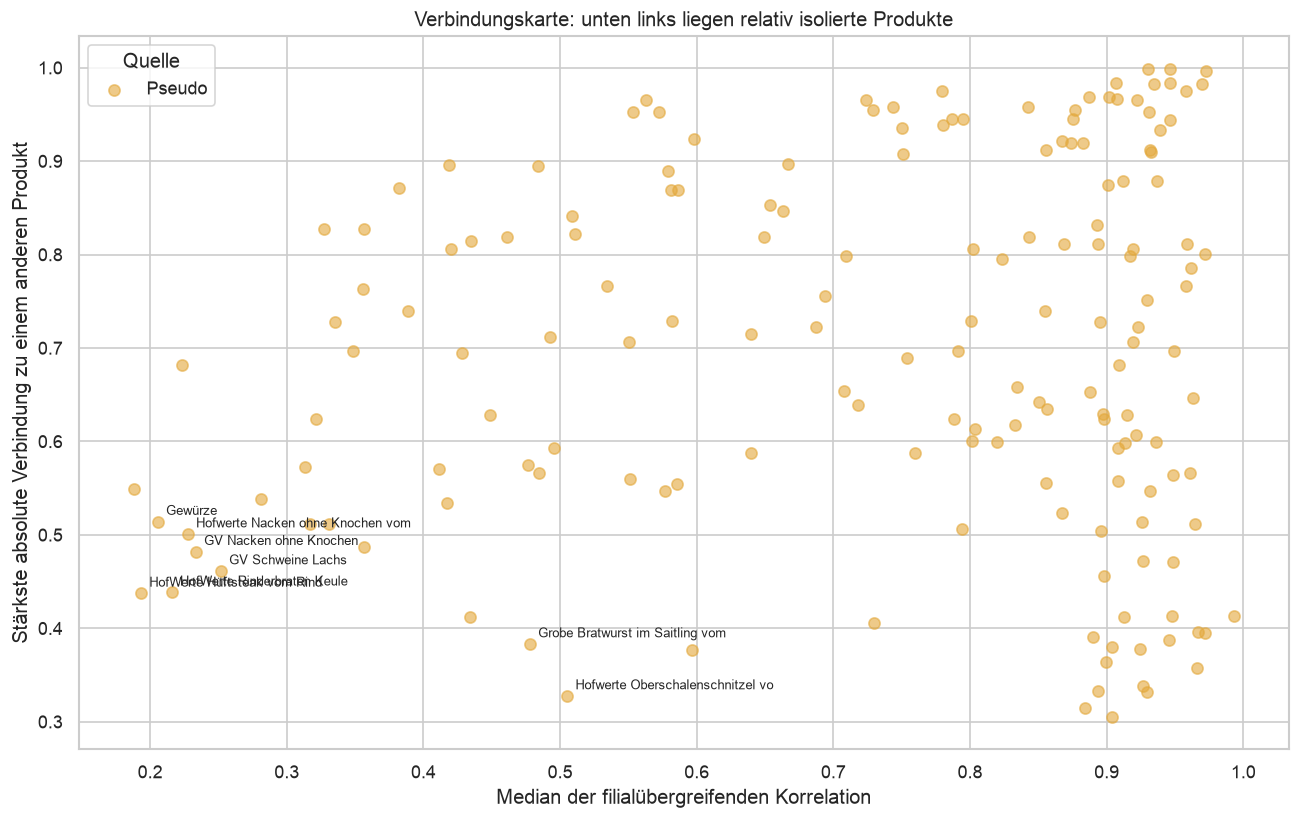

In [29]:
all_profiles = con.execute("""
    SELECT article_id, sales_week, profile_value
    FROM product_profile
""").fetchdf()

eligible_ids = analysis_metrics.article_id.tolist()
profile_wide = (
    all_profiles[all_profiles.article_id.isin(eligible_ids)]
    .pivot(index="sales_week", columns="article_id", values="profile_value")
)
profile_correlations = profile_wide.corr(min_periods=40)
np.fill_diagonal(profile_correlations.values, np.nan)
max_abs_product_corr = profile_correlations.abs().max(axis=1).rename("max_abs_product_correlation")

connectivity = analysis_metrics.merge(
    max_abs_product_corr,
    left_on="article_id",
    right_index=True,
    how="left",
)
connectivity["store_connection_rank"] = connectivity.median_store_correlation.rank(pct=True)
connectivity["product_connection_rank"] = connectivity.max_abs_product_correlation.rank(pct=True)
connectivity["isolation_score"] = (
    connectivity.store_connection_rank + connectivity.product_connection_rank
) / 2

isolated = connectivity.nsmallest(10, "isolation_score")
display(
    isolated[[
        "article_id", "product_name", "source_class", "eligible_stores",
        "median_store_correlation", "max_abs_product_correlation",
        "median_year_correlation", "seasonal_cv",
    ]].reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
for source_class, group in connectivity.groupby("source_class"):
    ax.scatter(
        group.median_store_correlation,
        group.max_abs_product_correlation,
        color=SOURCE_COLORS[source_class],
        alpha=0.6,
        s=45,
        label=source_class,
    )
for row in isolated.head(8).itertuples():
    ax.annotate(
        row.product_name[:32],
        (row.median_store_correlation, row.max_abs_product_correlation),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_xlabel("Median der filialübergreifenden Korrelation")
ax.set_ylabel("Stärkste absolute Verbindung zu einem anderen Produkt")
ax.set_title("Verbindungskarte: unten links liegen relativ isolierte Produkte")
ax.legend(title="Quelle")
plt.tight_layout()
plt.show()


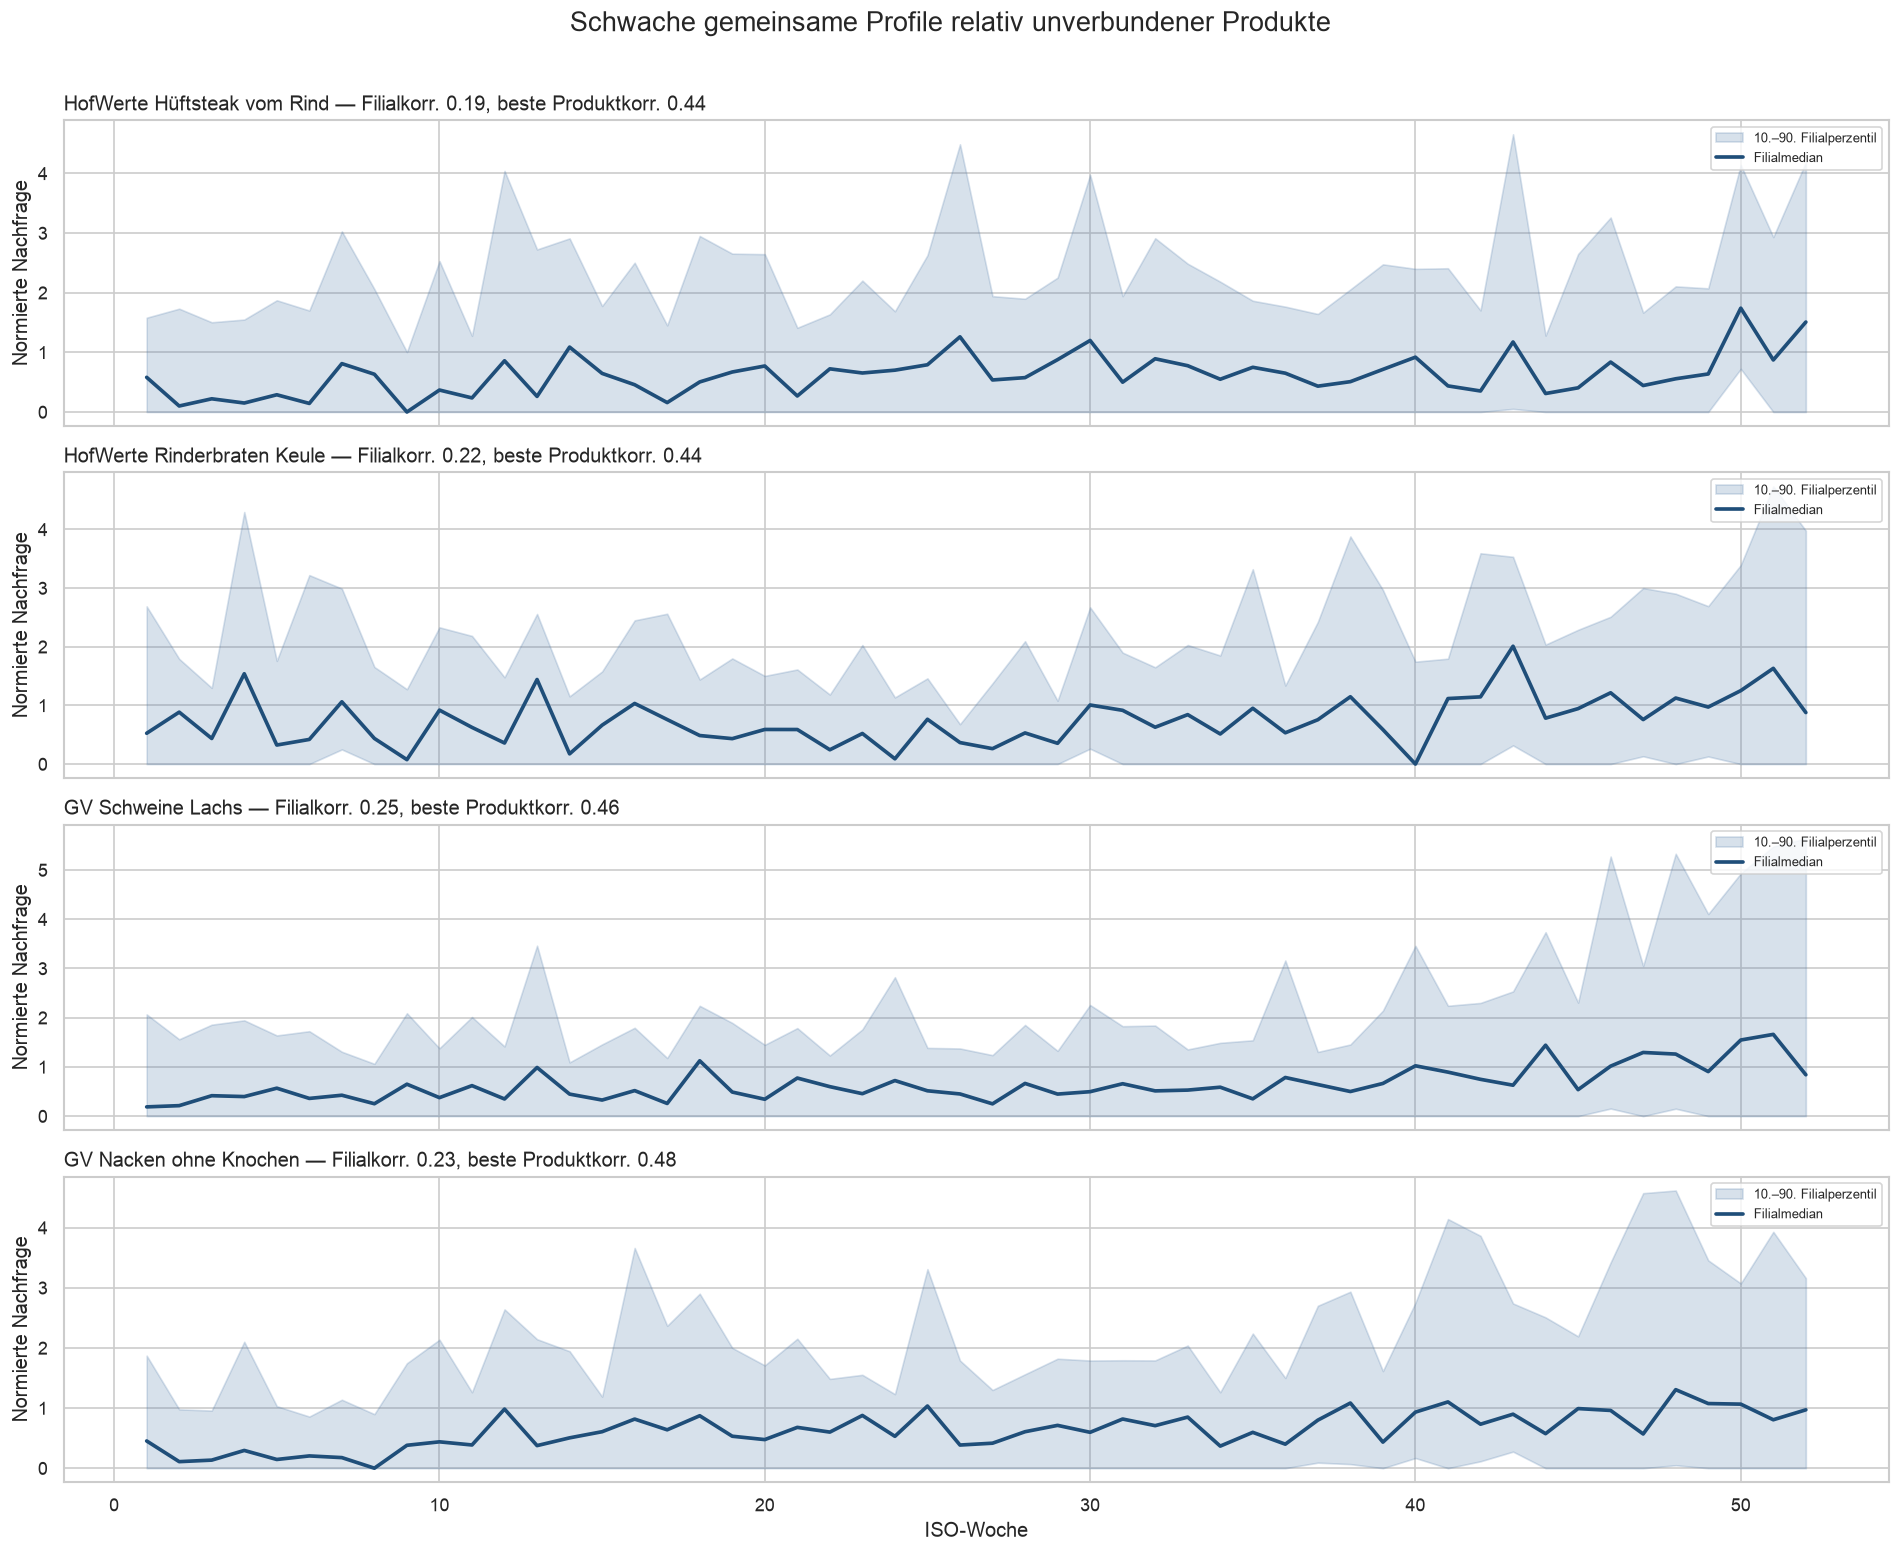

In [30]:
isolated_ids = isolated.head(4).article_id.tolist()

fig, axes = plt.subplots(len(isolated_ids), 1, figsize=(16, 3.2 * len(isolated_ids)), sharex=True)
if len(isolated_ids) == 1:
    axes = [axes]

for ax, article_id in zip(axes, isolated_ids):
    store_profiles = con.execute(f"""
        SELECT
            store_id,
            sales_week,
            avg(normalized_demand) AS normalized_demand
        FROM normalized_store_year_week
        WHERE article_id = {int(article_id)}
        GROUP BY store_id, sales_week
    """).fetchdf()
    matrix = store_profiles.pivot(
        index="store_id", columns="sales_week", values="normalized_demand"
    )
    median_profile = matrix.median(axis=0)
    lower_profile = matrix.quantile(0.10, axis=0)
    upper_profile = matrix.quantile(0.90, axis=0)
    ax.fill_between(
        matrix.columns,
        lower_profile,
        upper_profile,
        color="#4C78A8",
        alpha=0.22,
        label="10.–90. Filialperzentil",
    )
    ax.plot(matrix.columns, median_profile, color="#1F4E79", linewidth=2.2, label="Filialmedian")
    row = isolated[isolated.article_id == article_id].iloc[0]
    ax.set_title(
        f"{row.product_name} — Filialkorr. {row.median_store_correlation:.2f}, "
        f"beste Produktkorr. {row.max_abs_product_correlation:.2f}",
        loc="left",
    )
    ax.set_ylabel("Normierte Nachfrage")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("ISO-Woche")
fig.suptitle("Schwache gemeinsame Profile relativ unverbundener Produkte", fontsize=16, y=1.01)
fig.tight_layout()
plt.show()


## Interpretation notes

- The three family names are expert-readable labels applied after quantitative screening and profile comparison; they are not latent classes discovered without judgement.
- Easter must be aligned to the holiday date. A fixed ISO-week repeatability filter would incorrectly reject movable-holiday seasonality.
- High cross-store correlation is synchronized timing, not causality. Promotions, assortment rollouts, holidays, and weather can all produce it.
- ADI–CV² and seasonality are complementary: a series can sell frequently yet have a strong annual peak, or be sparse without a stable seasonal peak.
- FCM does not yet have the same complete-year history as Pseudo. Its family assignments remain provisional until another full annual cycle is available.
- “Disconnected” means weak relative connections under these definitions; it does not mean that a product is intrinsically unpredictable.